In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [2]:
data = pd.read_csv("data/liquidity_base.csv")

data

,Unnamed: 0,id,start_time,close_time,brand,model,generation,body_type,year,mileage,...,equipment,fuel_type,transmission,drive,color,region,condition,rating,reviews,removal_reason
0,0,263951,2024-07-20 16:51:47.744669,2024-08-14 20:35:34.353783,Kia,Sorento,I (2002—2006),Внедорожник,2002,290000,...,Базовая,Дизель,Автомат,Полный,Серый,Воронежская область,Не битый,5.00,4.00,Продано на Avito
1,1,223634,2024-07-17 15:35:34.290251,2024-07-19 11:38:22.750530,Kia,Sorento,II рестайлинг (2012—2021),Внедорожник,2014,131000,...,Classic,Бензин,Автомат,Полный,Серый,Москва,Не битый,NaN,NaN,NaN
2,2,282105,2024-07-22 10:19:17.534577,2024-07-31 18:29:03.218218,Toyota,Land Cruiser Prado,150 (2009—2013),Внедорожник,2012,250000,...,Elegance,Дизель,Автомат,Полный,Серый,Удмуртия,Не битый,5.00,11.00,Другая причина
3,3,108565,2024-07-08 22:11:23.788182,2024-09-07 10:38:38.021999,ВАЗ (LADA),Granta,I (2011—2018),Лифтбек,2016,150000,...,Comfort,Бензин,Механика,Передний,Синий,Башкортостан,Не битый,5.00,3.00,NaN
4,4,228568,2024-07-17 20:49:44.749832,2024-09-04 08:19:21.514770,Volkswagen,Polo,V (2009—2015),Седан,2013,213433,...,NaN,Бензин,Механика,Передний,Синий,Ставропольский край,Не битый,2.00,1.00,Продано на Avito
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412796,412796,325503,2024-07-25 12:43:41.231182,2024-09-07 16:33:12.437868,JAC,JS4,I (2020—2026),Внедорожник,2022,8000,...,NaN,Бензин,Вариатор,Передний,Белый,Тюменская область,Не битый,4.63,52.00,Нет ответа
412797,412797,401783,2024-07-31 11:33:33.744780,2024-08-01 14:32:32.794333,ВАЗ (LADA),Vesta,I (2015—2023),Седан,2021,80413,...,Comfort,Бензин,Вариатор,Передний,Белый,Пермский край,Не битый,5.00,3.00,Продано на Avito
412798,412798,1230,2024-07-01 08:50:20.009251,2024-07-09 12:09:51.688507,Kia,K7,II рестайлинг (2019—2021),Седан,2019,16000,...,Базовая,Бензин,Автомат,Передний,Белый,Иркутская область,Не битый,NaN,NaN,NaN
412799,412799,66739,2024-07-05 16:18:51.199832,2024-09-03 07:00:48.254334,ВАЗ (LADA),Granta,I рестайлинг (2018—2026),Седан,2023,48000,...,Standard,Бензин,Механика,Передний,Белый,Краснодарский край,Не битый,5.00,1.00,Другая причина


Поскольку цель, грубо говоря, выдать рекомендации для каждого клиента, для этих самых рекомендаций для каждой машины в общем стоит использовать только: year  mileage fuel_type transmission drive ?color? region condition rating reviews

In [3]:
data = data.drop(["Unnamed: 0"], axis = 1)

In [4]:
display(data.dtypes)

id                  int64
start_time            str
close_time            str
brand                 str
model                 str
generation            str
body_type             str
year                int64
mileage             int64
price             float64
imv               float64
modification          str
equipment             str
fuel_type             str
transmission          str
drive                 str
color                 str
region                str
condition             str
rating            float64
reviews           float64
removal_reason        str
dtype: object

In [5]:
# num_data = data.copy()

# all_mappings = {}

# for col in data.select_dtypes(include="str").columns:
#     categories = data[col].astype("category").cat.categories
#     all_mappings[col] = {v: k for k, v in dict(enumerate(categories)).items()}
#     num_data[col] = data[col].map(all_mappings[col])



In [6]:
# Считаем количество каждого бренда
brand_counts = data["brand"].value_counts()

# Находим редкие бренды
unus = brand_counts[brand_counts < 15]

display(unus)

data = data[~data["brand"].isin(unus)].copy()
print(f"Осталось строк: {len(data)}")

brand
ZX          14
JMC         12
Lancia      12
Scion       12
McLaren     11
            ..
Wartburg     1
ЗиС          1
DeLorean     1
Sokon        1
iCAR         1
Name: count, Length: 93, dtype: int64

Осталось строк: 412801


На основе < 15 строк данных рекомендации, которые будут адекватны в сути, составить невозможно, следовательно можно удалить

In [7]:
display(data.value_counts()) #! - собсна, не показывает ничего(

id      start_time                  close_time                  brand       model               generation                 body_type    year  mileage  price       imv         modification                equipment       fuel_type  transmission  drive     color   region               condition  rating  reviews  removal_reason    
263951  2024-07-20 16:51:47.744669  2024-08-14 20:35:34.353783  Kia         Sorento             I (2002—2006)              Внедорожник  2002  290000   630000.00   548900.00   2.5 CRDi 4WD AT (140 л.с.)  Базовая         Дизель     Автомат       Полный    Серый   Воронежская область  Не битый   5.00    4.00     Продано на Avito      1
282105  2024-07-22 10:19:17.534577  2024-07-31 18:29:03.218218  Toyota      Land Cruiser Prado  150 (2009—2013)            Внедорожник  2012  250000   2749000.00  2883500.00  3.0 D AT (173 л.с.)         Elegance        Дизель     Автомат       Полный    Серый   Удмуртия             Не битый   5.00    11.00    Другая причина        1


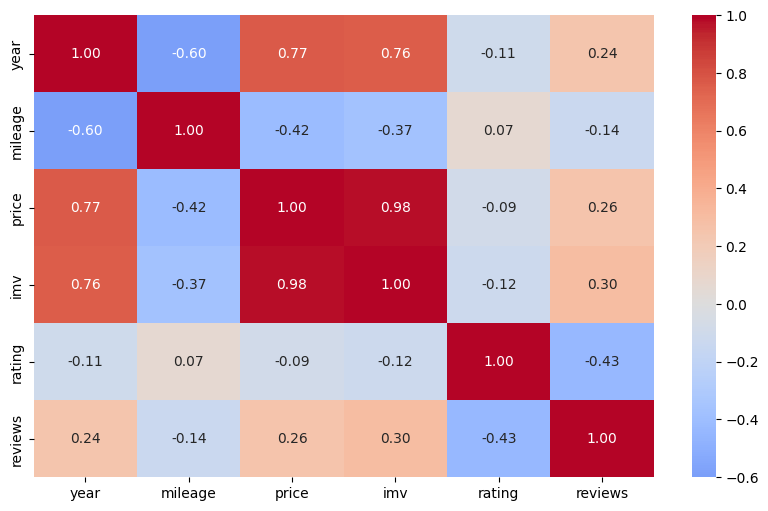

In [8]:
num_cols = ["year", "mileage", "price", "imv", "rating", "reviews"]


corr = data[num_cols].corr(method="spearman")

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.show()

#Интересно

Теория: главное - пробег х год, рейтинг х отзывы

контринтуитивно - год х цена, имв х год, 

In [9]:
data.describe()

,id,year,mileage,price,imv,rating,reviews
count,412801.00,412801.00,412801.00,412801.00,343683.00,307396.00,307396.00
mean,206401.00,2010.82,163014.36,1313355.07,973766.53,4.63,210.76
std,119165.53,7.87,103836.73,9910799.02,1268547.90,0.67,787.35
min,1.00,1928.00,1.00,1.00,3400.00,1.00,1.00
25%,103201.00,2007.00,88540.00,340000.00,297300.00,4.54,3.00
50%,206401.00,2011.00,155000.00,750000.00,644200.00,4.89,12.00
75%,309601.00,2017.00,220000.00,1480000.00,1216900.00,5.00,72.00
max,412801.00,2026.00,1000000.00,5000000000.00,75072500.00,5.00,9901.00


In [10]:
# Number of null values 'in each column
data.isna().sum()

id                     0
start_time             0
close_time             0
brand                  0
model                  0
generation           161
body_type              0
year                   0
mileage                0
price                  0
imv                69118
modification         714
equipment          95499
fuel_type              0
transmission           0
drive                  0
color                  0
region                 0
condition              0
rating            105405
reviews           105405
removal_reason     61625
dtype: int64

# Пожалуй, можно пренебречь (ИЛи же рассматриват ьв последнюю очередь) пропусками в поколении, модификации, причиной удаления. Также рейтинг +-, поскольку может быть выставлен впервые

In [11]:
data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
412796    False
412797    False
412798    False
412799    False
412800    False
Length: 412801, dtype: bool

In [12]:
data.drop_duplicates()

,id,start_time,close_time,brand,model,generation,body_type,year,mileage,price,...,equipment,fuel_type,transmission,drive,color,region,condition,rating,reviews,removal_reason
0,263951,2024-07-20 16:51:47.744669,2024-08-14 20:35:34.353783,Kia,Sorento,I (2002—2006),Внедорожник,2002,290000,630000.00,...,Базовая,Дизель,Автомат,Полный,Серый,Воронежская область,Не битый,5.00,4.00,Продано на Avito
1,223634,2024-07-17 15:35:34.290251,2024-07-19 11:38:22.750530,Kia,Sorento,II рестайлинг (2012—2021),Внедорожник,2014,131000,1530000.00,...,Classic,Бензин,Автомат,Полный,Серый,Москва,Не битый,NaN,NaN,NaN
2,282105,2024-07-22 10:19:17.534577,2024-07-31 18:29:03.218218,Toyota,Land Cruiser Prado,150 (2009—2013),Внедорожник,2012,250000,2749000.00,...,Elegance,Дизель,Автомат,Полный,Серый,Удмуртия,Не битый,5.00,11.00,Другая причина
3,108565,2024-07-08 22:11:23.788182,2024-09-07 10:38:38.021999,ВАЗ (LADA),Granta,I (2011—2018),Лифтбек,2016,150000,529000.00,...,Comfort,Бензин,Механика,Передний,Синий,Башкортостан,Не битый,5.00,3.00,NaN
4,228568,2024-07-17 20:49:44.749832,2024-09-04 08:19:21.514770,Volkswagen,Polo,V (2009—2015),Седан,2013,213433,685000.00,...,NaN,Бензин,Механика,Передний,Синий,Ставропольский край,Не битый,2.00,1.00,Продано на Avito
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412796,325503,2024-07-25 12:43:41.231182,2024-09-07 16:33:12.437868,JAC,JS4,I (2020—2026),Внедорожник,2022,8000,1698000.00,...,NaN,Бензин,Вариатор,Передний,Белый,Тюменская область,Не битый,4.63,52.00,Нет ответа
412797,401783,2024-07-31 11:33:33.744780,2024-08-01 14:32:32.794333,ВАЗ (LADA),Vesta,I (2015—2023),Седан,2021,80413,1010000.00,...,Comfort,Бензин,Вариатор,Передний,Белый,Пермский край,Не битый,5.00,3.00,Продано на Avito
412798,1230,2024-07-01 08:50:20.009251,2024-07-09 12:09:51.688507,Kia,K7,II рестайлинг (2019—2021),Седан,2019,16000,2490000.00,...,Базовая,Бензин,Автомат,Передний,Белый,Иркутская область,Не битый,NaN,NaN,NaN
412799,66739,2024-07-05 16:18:51.199832,2024-09-03 07:00:48.254334,ВАЗ (LADA),Granta,I рестайлинг (2018—2026),Седан,2023,48000,1100000.00,...,Standard,Бензин,Механика,Передний,Белый,Краснодарский край,Не битый,5.00,1.00,Другая причина


In [13]:
data["removal_reason"].sample(20)

89674       Продано на Avito
203225            Нет ответа
170847      Продано на Avito
357850        Другая причина
361161    Продано где-то ещё
98373             Нет ответа
384765            Нет ответа
349568                   NaN
205882                   NaN
249371      Продано на Avito
390441                   NaN
37385     Продано где-то ещё
356541                   NaN
375387    Продано где-то ещё
211300        Другая причина
275314      Продано на Avito
94845       Продано на Avito
360637    Продано где-то ещё
80874         Другая причина
85563                    NaN
Name: removal_reason, dtype: str

In [14]:
data["removal_reason"].value_counts()

removal_reason
Продано на Avito      128800
Другая причина        117564
Нет ответа             64613
Продано где-то ещё     40199
Name: count, dtype: int64

In [15]:
sended_data = data[data["removal_reason"] == "Продано на Avito"].copy()
not_sended_data = data[data["removal_reason"] != "Продано на Avito"].copy()

sended_data

,id,start_time,close_time,brand,model,generation,body_type,year,mileage,price,...,equipment,fuel_type,transmission,drive,color,region,condition,rating,reviews,removal_reason
0,263951,2024-07-20 16:51:47.744669,2024-08-14 20:35:34.353783,Kia,Sorento,I (2002—2006),Внедорожник,2002,290000,630000.00,...,Базовая,Дизель,Автомат,Полный,Серый,Воронежская область,Не битый,5.00,4.00,Продано на Avito
4,228568,2024-07-17 20:49:44.749832,2024-09-04 08:19:21.514770,Volkswagen,Polo,V (2009—2015),Седан,2013,213433,685000.00,...,NaN,Бензин,Механика,Передний,Синий,Ставропольский край,Не битый,2.00,1.00,Продано на Avito
7,373538,2024-07-29 11:02:12.956599,2024-09-11 21:32:50.500176,Infiniti,QX4,I (1996—2003),Внедорожник,2000,250000,570000.00,...,Базовая,Бензин,Автомат,Полный,Чёрный,Алтайский край,Не битый,4.54,26.00,Продано на Avito
17,182952,2024-07-14 16:37:41.379018,2024-07-22 09:35:48.962725,ВАЗ (LADA),Granta,I рестайлинг (2018—2026),Седан,2021,81685,800000.00,...,NaN,Бензин,Механика,Передний,Серый,Ростовская область,Битый,NaN,NaN,Продано на Avito
18,282282,2024-07-22 10:32:12.943631,2024-07-23 15:39:59.935750,ВАЗ (LADA),2107,I (1982—2012),Седан,2010,57000,220000.00,...,Базовая,Бензин,Механика,Задний,Серый,Краснодарский край,Битый,NaN,NaN,Продано на Avito
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412788,290674,2024-07-22 19:29:03.887095,2024-07-27 11:01:28.060507,Skoda,Octavia,I рестайлинг (2000—2011),Лифтбек,2000,400000,250000.00,...,Base,Бензин,Механика,Передний,Зелёный,Новгородская область,Не битый,NaN,NaN,Продано на Avito
412789,256669,2024-07-19 22:29:07.960802,2024-09-05 19:22:29.538466,Lexus,IS,I (1999—2005),Седан,1999,270910,970000.00,...,Базовая,Бензин,Автомат,Задний,Чёрный,Калининградская область,Не битый,5.00,59.00,Продано на Avito
412793,382704,2024-07-29 20:15:59.154296,2024-09-05 20:30:52.002824,Opel,Astra,H рестайлинг (2006—2014),Хетчбэк,2008,234200,550000.00,...,NaN,Бензин,Автомат,Передний,Чёрный,Карелия,Не битый,NaN,NaN,Продано на Avito
412794,402543,2024-07-31 12:18:24.989677,2024-08-05 20:11:38.068717,ВАЗ (LADA),Priora,I (2007—2013),Универсал,2009,210000,487000.00,...,Люкс,Бензин,Механика,Передний,Чёрный,Ростовская область,Не битый,5.00,1.00,Продано на Avito


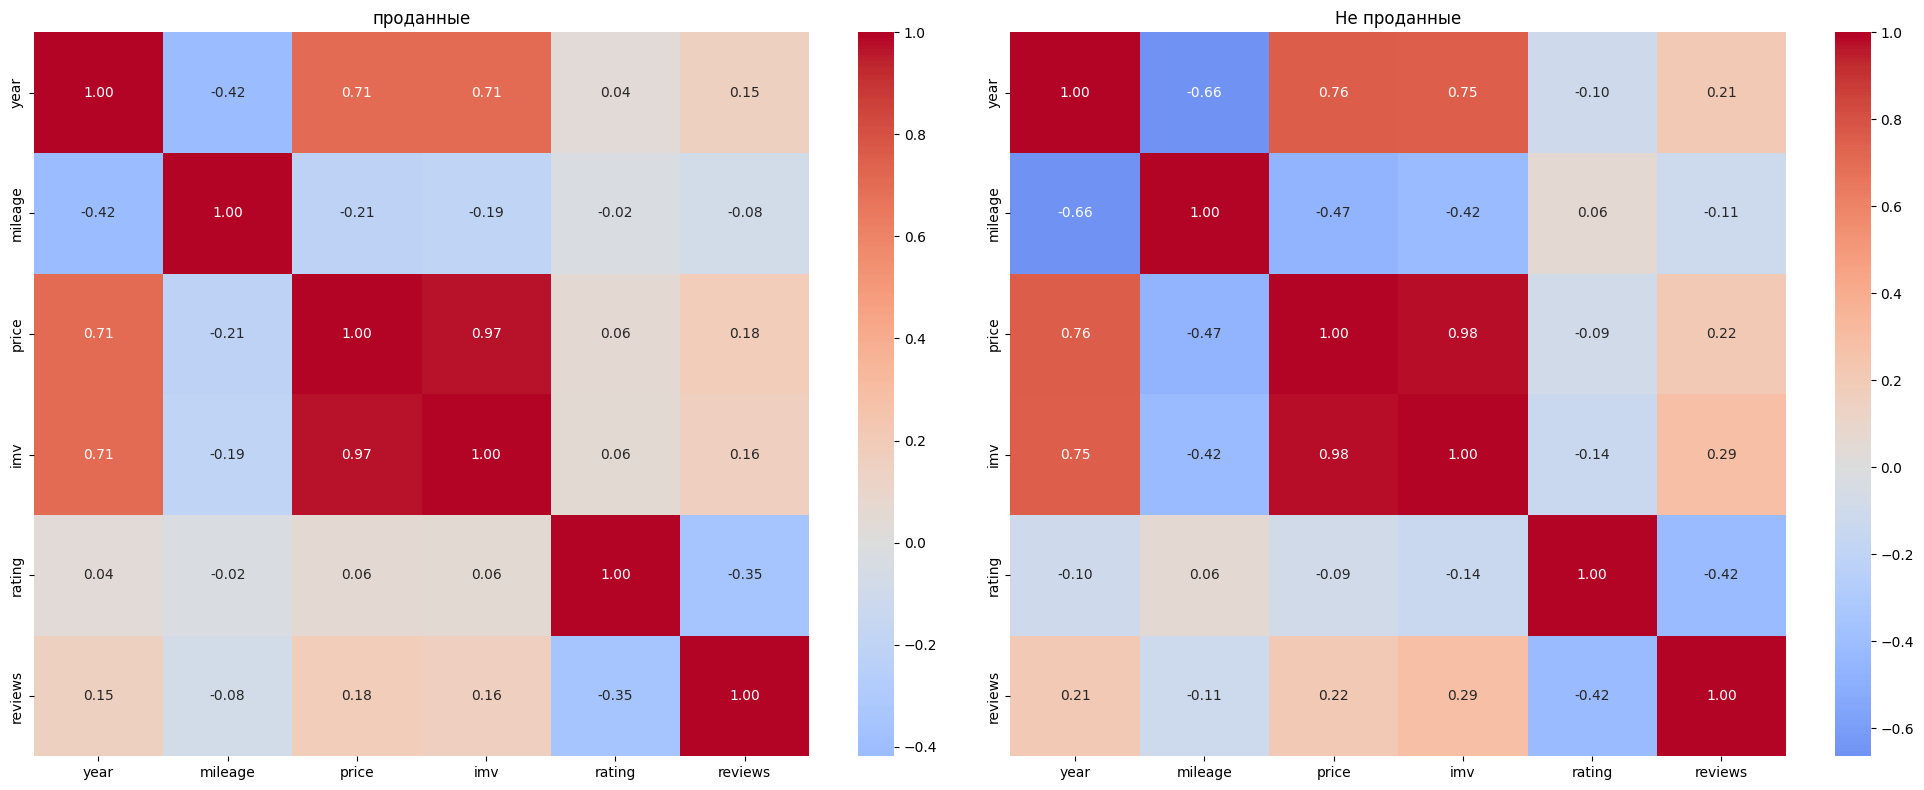

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

num_cols = ["year", "mileage", "price", "imv", "rating", "reviews"]

# Первая матрица
corr1 = sended_data[num_cols].corr(method="spearman")
sns.heatmap(corr1, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("проданные")

# Вторая матрица
corr2 = not_sended_data[num_cols].corr(method="spearman")
sns.heatmap(corr2, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Не проданные")

plt.tight_layout()
plt.show()

Отличия sended от not_sended: пробег х год, рейтинг х отзывы, пробег х цена

In [17]:
data_cnt = pd.read_csv("data/liquidity_cnt.csv")

display(data_cnt["day"].value_counts())
data_cnt["cnt_contacts"].value_counts()

day
1     181241
2     144229
3     128525
4     108172
5      98178
       ...  
86       152
87       112
88        64
89        38
90        13
Name: count, Length: 90, dtype: int64

cnt_contacts
1      1156747
2       469672
3       248206
4       146815
5        92930
        ...   
226          1
141          1
834          1
691          1
640          1
Name: count, Length: 268, dtype: int64

In [18]:
data_cnt

,Unnamed: 0,id,day,cnt_contacts
0,0,75908,1,1
1,1,100916,18,2
2,2,159243,14,1
3,3,207651,43,1
4,4,14109,14,3
...,...,...,...,...
2359585,2359585,93657,12,4
2359586,2359586,66439,19,1
2359587,2359587,215937,61,3
2359588,2359588,73076,44,1


In [19]:
data_cnt["id"].duplicated().sum() #Ne Круто(

np.int64(2028738)

In [20]:
display(data_cnt.describe())
p90 = data_cnt['day'].quantile(0.85)
print(p90)

,Unnamed: 0,id,day,cnt_contacts
count,2359590.00,2359590.00,2359590.00,2359590.00
mean,1179794.50,201969.15,17.51,2.77
std,681155.11,118405.72,16.14,5.44
min,0.00,1.00,1.00,1.00
25%,589897.25,99002.00,5.00,1.00
50%,1179794.50,199795.00,13.00,2.00
75%,1769691.75,303457.00,25.00,3.00
max,2359589.00,412801.00,90.00,2894.00


34.0


In [21]:
agg = data_cnt.groupby("id").agg(
    total_contacts = ("cnt_contacts", "sum"),      # всего контактов
    active_days    = ("day", "nunique"),            # сколько дней были контакты
    first_day_contacts = ("cnt_contacts", "first"), # контакты в первый день
    max_daily      = ("cnt_contacts", "max"),       # пик за день
    avg_daily      = ("cnt_contacts", "mean"),      # среднее в день
).reset_index()

# Присоединяем к основной таблице
data_full = data.merge(agg, on="id", how="left")

data_full

,id,start_time,close_time,brand,model,generation,body_type,year,mileage,price,...,region,condition,rating,reviews,removal_reason,total_contacts,active_days,first_day_contacts,max_daily,avg_daily
0,263951,2024-07-20 16:51:47.744669,2024-08-14 20:35:34.353783,Kia,Sorento,I (2002—2006),Внедорожник,2002,290000,630000.00,...,Воронежская область,Не битый,5.00,4.00,Продано на Avito,69.00,20.00,2.00,9.00,3.45
1,223634,2024-07-17 15:35:34.290251,2024-07-19 11:38:22.750530,Kia,Sorento,II рестайлинг (2012—2021),Внедорожник,2014,131000,1530000.00,...,Москва,Не битый,NaN,NaN,NaN,1.00,1.00,1.00,1.00,1.00
2,282105,2024-07-22 10:19:17.534577,2024-07-31 18:29:03.218218,Toyota,Land Cruiser Prado,150 (2009—2013),Внедорожник,2012,250000,2749000.00,...,Удмуртия,Не битый,5.00,11.00,Другая причина,4.00,2.00,2.00,2.00,2.00
3,108565,2024-07-08 22:11:23.788182,2024-09-07 10:38:38.021999,ВАЗ (LADA),Granta,I (2011—2018),Лифтбек,2016,150000,529000.00,...,Башкортостан,Не битый,5.00,3.00,NaN,5.00,4.00,2.00,2.00,1.25
4,228568,2024-07-17 20:49:44.749832,2024-09-04 08:19:21.514770,Volkswagen,Polo,V (2009—2015),Седан,2013,213433,685000.00,...,Ставропольский край,Не битый,2.00,1.00,Продано на Avito,67.00,25.00,1.00,13.00,2.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412796,325503,2024-07-25 12:43:41.231182,2024-09-07 16:33:12.437868,JAC,JS4,I (2020—2026),Внедорожник,2022,8000,1698000.00,...,Тюменская область,Не битый,4.63,52.00,Нет ответа,2.00,2.00,1.00,1.00,1.00
412797,401783,2024-07-31 11:33:33.744780,2024-08-01 14:32:32.794333,ВАЗ (LADA),Vesta,I (2015—2023),Седан,2021,80413,1010000.00,...,Пермский край,Не битый,5.00,3.00,Продано на Avito,NaN,NaN,NaN,NaN,NaN
412798,1230,2024-07-01 08:50:20.009251,2024-07-09 12:09:51.688507,Kia,K7,II рестайлинг (2019—2021),Седан,2019,16000,2490000.00,...,Иркутская область,Не битый,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
412799,66739,2024-07-05 16:18:51.199832,2024-09-03 07:00:48.254334,ВАЗ (LADA),Granta,I рестайлинг (2018—2026),Седан,2023,48000,1100000.00,...,Краснодарский край,Не битый,5.00,1.00,Другая причина,NaN,NaN,NaN,NaN,NaN


In [22]:
# Number of null values 'in each column
data_full.isna().sum()



id                         0
start_time                 0
close_time                 0
brand                      0
model                      0
generation               161
body_type                  0
year                       0
mileage                    0
price                      0
imv                    69118
modification             714
equipment              95499
fuel_type                  0
transmission               0
drive                      0
color                      0
region                     0
condition                  0
rating                105405
reviews               105405
removal_reason         61625
total_contacts         81949
active_days            81949
first_day_contacts     81949
max_daily              81949
avg_daily              81949
dtype: int64

In [23]:
data_full["price_ratio"] = data_full["price"] / data_full["imv"]
# > 1.0 = переоценено, < 1.0 = недооценено

пожалуй, там где нет информации по дням, строки можно удалить 

In [24]:
# Сначала dropna без price_ratio
new_cols = ["total_contacts", "active_days", "first_day_contacts", "max_daily", "avg_daily"]
data_full = data_full.dropna(subset=new_cols)

# Потом считаем price_ratio — у битых останется NaN, это нормально
data_full["price_ratio"] = data_full["price"] / data_full["imv"]

data_full


,id,start_time,close_time,brand,model,generation,body_type,year,mileage,price,...,condition,rating,reviews,removal_reason,total_contacts,active_days,first_day_contacts,max_daily,avg_daily,price_ratio
0,263951,2024-07-20 16:51:47.744669,2024-08-14 20:35:34.353783,Kia,Sorento,I (2002—2006),Внедорожник,2002,290000,630000.00,...,Не битый,5.00,4.00,Продано на Avito,69.00,20.00,2.00,9.00,3.45,1.15
1,223634,2024-07-17 15:35:34.290251,2024-07-19 11:38:22.750530,Kia,Sorento,II рестайлинг (2012—2021),Внедорожник,2014,131000,1530000.00,...,Не битый,NaN,NaN,NaN,1.00,1.00,1.00,1.00,1.00,0.89
2,282105,2024-07-22 10:19:17.534577,2024-07-31 18:29:03.218218,Toyota,Land Cruiser Prado,150 (2009—2013),Внедорожник,2012,250000,2749000.00,...,Не битый,5.00,11.00,Другая причина,4.00,2.00,2.00,2.00,2.00,0.95
3,108565,2024-07-08 22:11:23.788182,2024-09-07 10:38:38.021999,ВАЗ (LADA),Granta,I (2011—2018),Лифтбек,2016,150000,529000.00,...,Не битый,5.00,3.00,NaN,5.00,4.00,2.00,2.00,1.25,1.07
4,228568,2024-07-17 20:49:44.749832,2024-09-04 08:19:21.514770,Volkswagen,Polo,V (2009—2015),Седан,2013,213433,685000.00,...,Не битый,2.00,1.00,Продано на Avito,67.00,25.00,1.00,13.00,2.68,1.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412792,302584,2024-07-23 17:36:29.299255,2024-09-21 19:21:15.007461,Ford,Escape,I (2000—2004),Внедорожник,2001,300001,250000.00,...,Не битый,4.57,7.00,Продано где-то ещё,25.00,18.00,1.00,4.00,1.39,0.83
412793,382704,2024-07-29 20:15:59.154296,2024-09-05 20:30:52.002824,Opel,Astra,H рестайлинг (2006—2014),Хетчбэк,2008,234200,550000.00,...,Не битый,NaN,NaN,Продано на Avito,19.00,12.00,1.00,4.00,1.58,1.24
412794,402543,2024-07-31 12:18:24.989677,2024-08-05 20:11:38.068717,ВАЗ (LADA),Priora,I (2007—2013),Универсал,2009,210000,487000.00,...,Не битый,5.00,1.00,Продано на Avito,12.00,3.00,3.00,8.00,4.00,1.43
412795,114672,2024-07-09 13:25:42.008523,2024-08-27 20:03:12.536420,Hyundai,Sonata,IV рестайлинг (2001—2012),Седан,2002,266715,429990.00,...,Не битый,4.40,1263.00,Нет ответа,2.00,2.00,1.00,1.00,1.00,1.43


Столбец
Расшифровка
- total_contacts Общее количество контактов за всё время жизни объявления
- active_days Количество дней, в которые было хотя бы одно обращение
- first_day_contactsКоличество контактов в первый день размещения 
- max_daily Максимальное количество контактов за один день (пик) 
- avg_daily Среднее количество контактов в день на протяжении всей жизни объявления

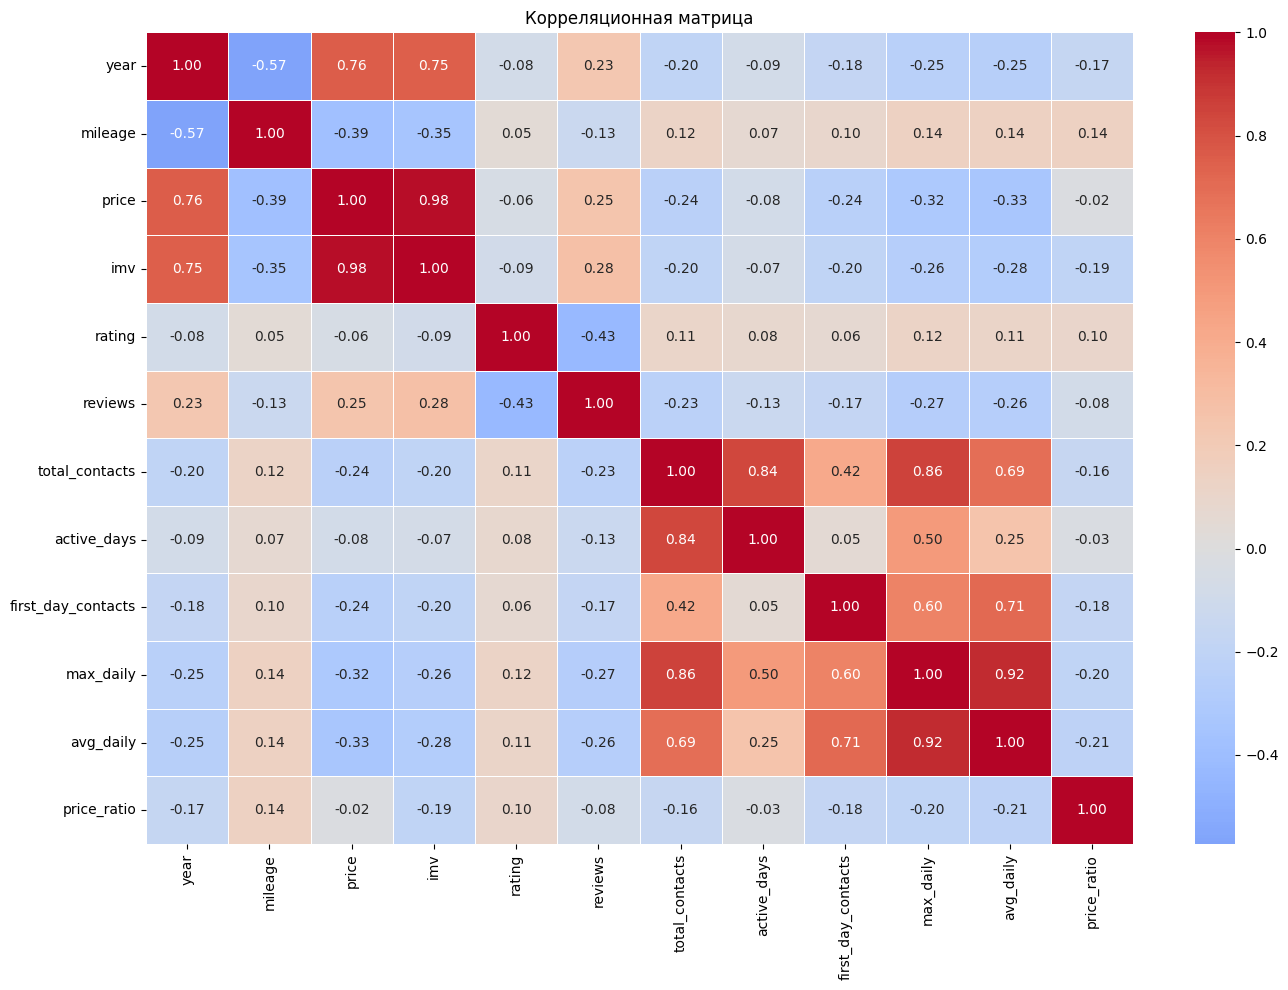

In [25]:
num_cols = [
    "year", "mileage", "price", "imv", 
    "rating", "reviews",
    "total_contacts", "active_days", 
    "first_day_contacts", "max_daily", "avg_daily", "price_ratio"
]

corr = data_full[num_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

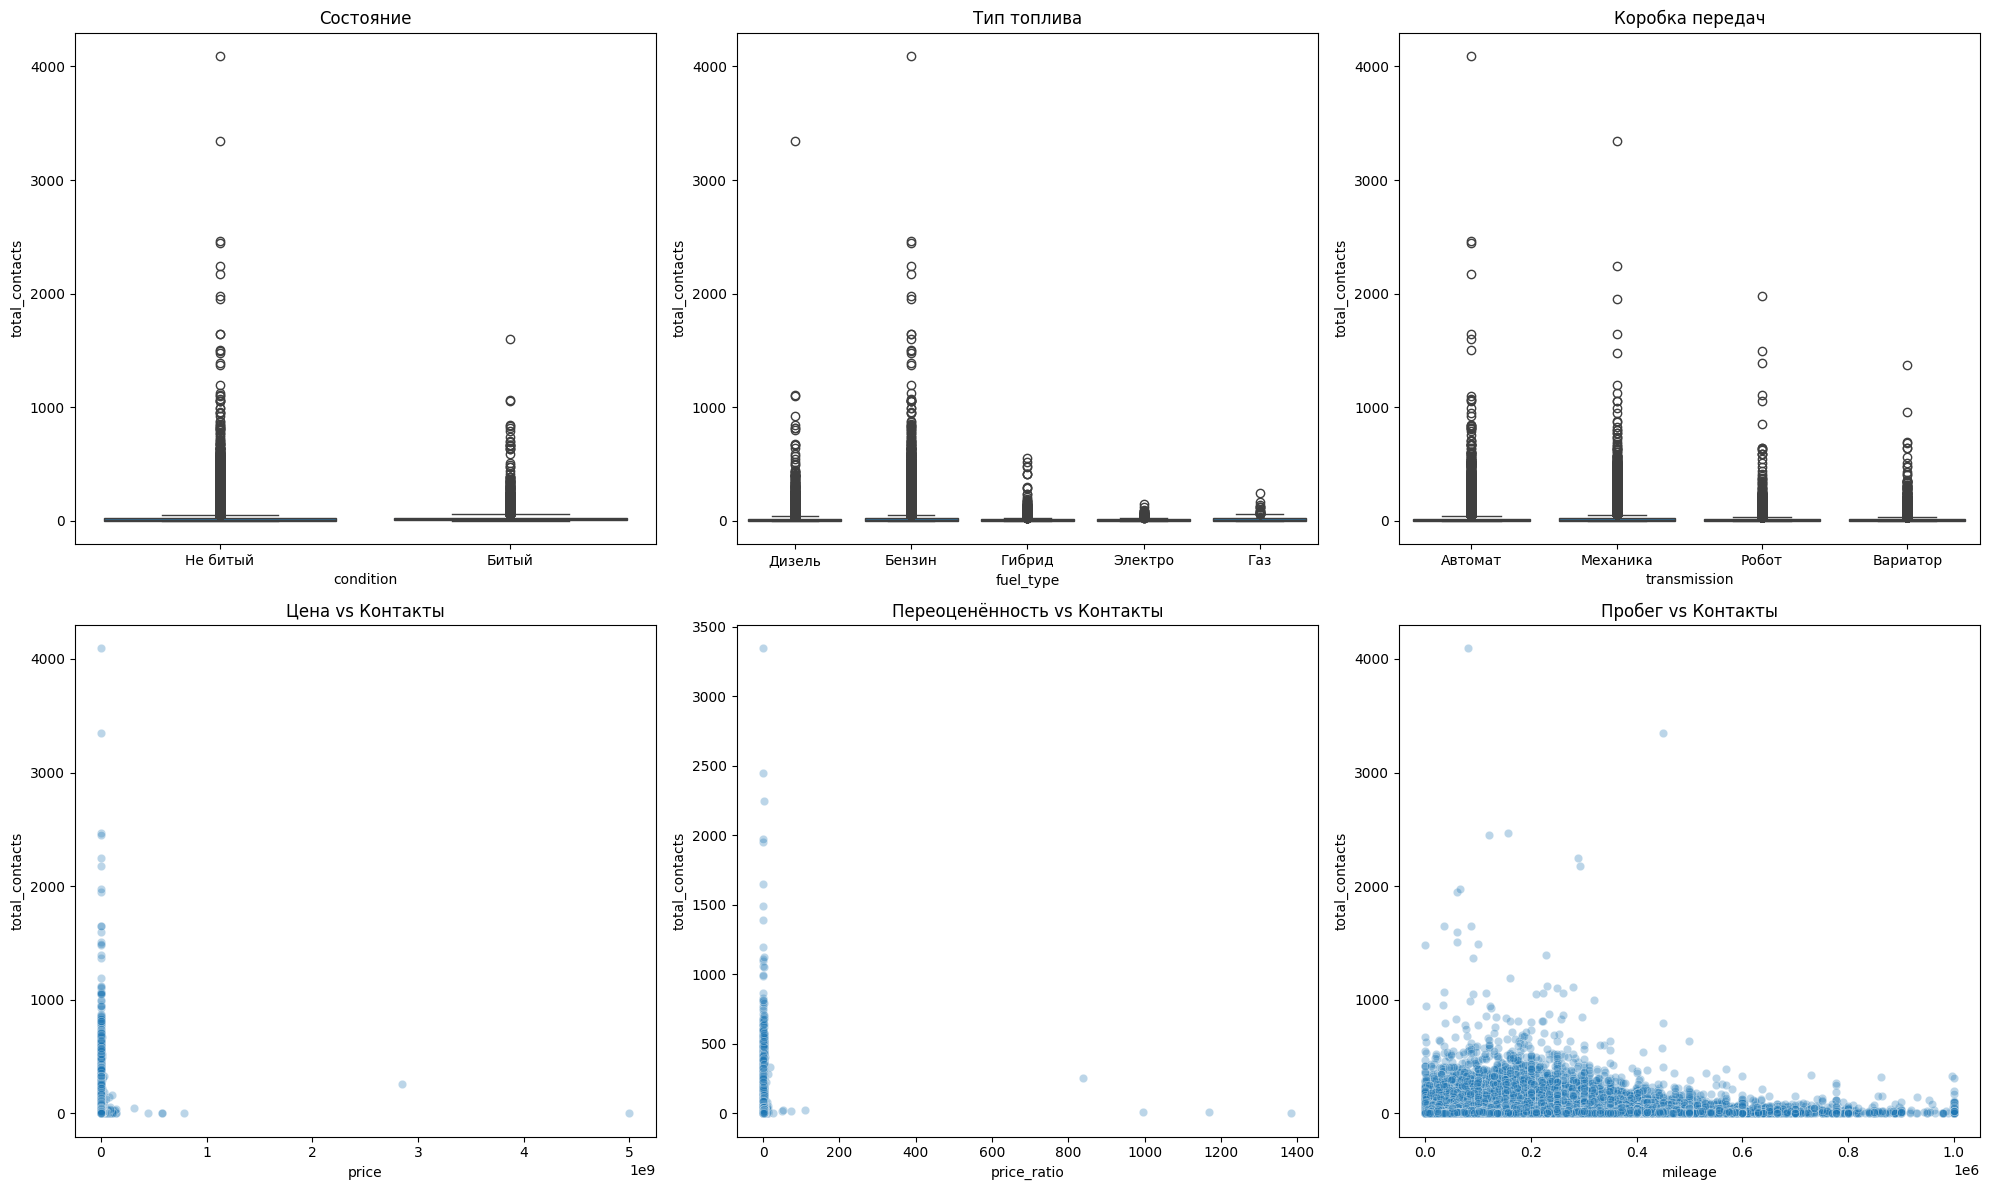

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Верхний ряд — категориальные
sns.boxplot(data=data_full, x="condition", y="total_contacts", ax=axes[0][0])
axes[0][0].set_title("Состояние")

sns.boxplot(data=data_full, x="fuel_type", y="total_contacts", ax=axes[0][1])
axes[0][1].set_title("Тип топлива")

sns.boxplot(data=data_full, x="transmission", y="total_contacts", ax=axes[0][2])
axes[0][2].set_title("Коробка передач")

# Нижний ряд — числовые через scatter
sns.scatterplot(data=data_full, x="price", y="total_contacts", alpha=0.3, ax=axes[1][0])
axes[1][0].set_title("Цена vs Контакты")

sns.scatterplot(data=data_full, x="price_ratio", y="total_contacts", alpha=0.3, ax=axes[1][1])
axes[1][1].set_title("Переоценённость vs Контакты")

sns.scatterplot(data=data_full, x="mileage", y="total_contacts", alpha=0.3, ax=axes[1][2])
axes[1][2].set_title("Пробег vs Контакты")

plt.tight_layout()
plt.show()

Можно заметить выбросы в цене и переоценке

In [27]:
print(data_full["price"].quantile(0.70))
print(data_full["price"].quantile(0.80))
print(data_full["price"].quantile(0.90))
print(data_full["price"].quantile(0.95))
print(data_full["price"].quantile(0.98))
print(data_full["price"].quantile(0.99))

1230000.0
1650000.0
2500000.0
3690000.0
6150000.0
8570000.0


In [28]:
print(data_full["price_ratio"].quantile(0.99))


2.180113731425008


Можно отрезать 1 верхний процент - вероятнее всего, они не повлияют на результат. Также переоценка более чем в два раза точно не помогает статистике

In [29]:
upper = data_full["price"].quantile(0.99)
data_full = data_full[data_full["price"] < upper]

# price_ratio фильтруем только для небитых
upper_ratio = data_full[data_full["condition"] == "Не битый"]["price_ratio"].quantile(0.99)
data_full = data_full[
    (data_full["price_ratio"] < upper_ratio) | 
    (data_full["condition"] == "Битый")
].copy()

print(data_full["condition"].value_counts())



condition
Не битый    274703
Битый        10404
Name: count, dtype: int64


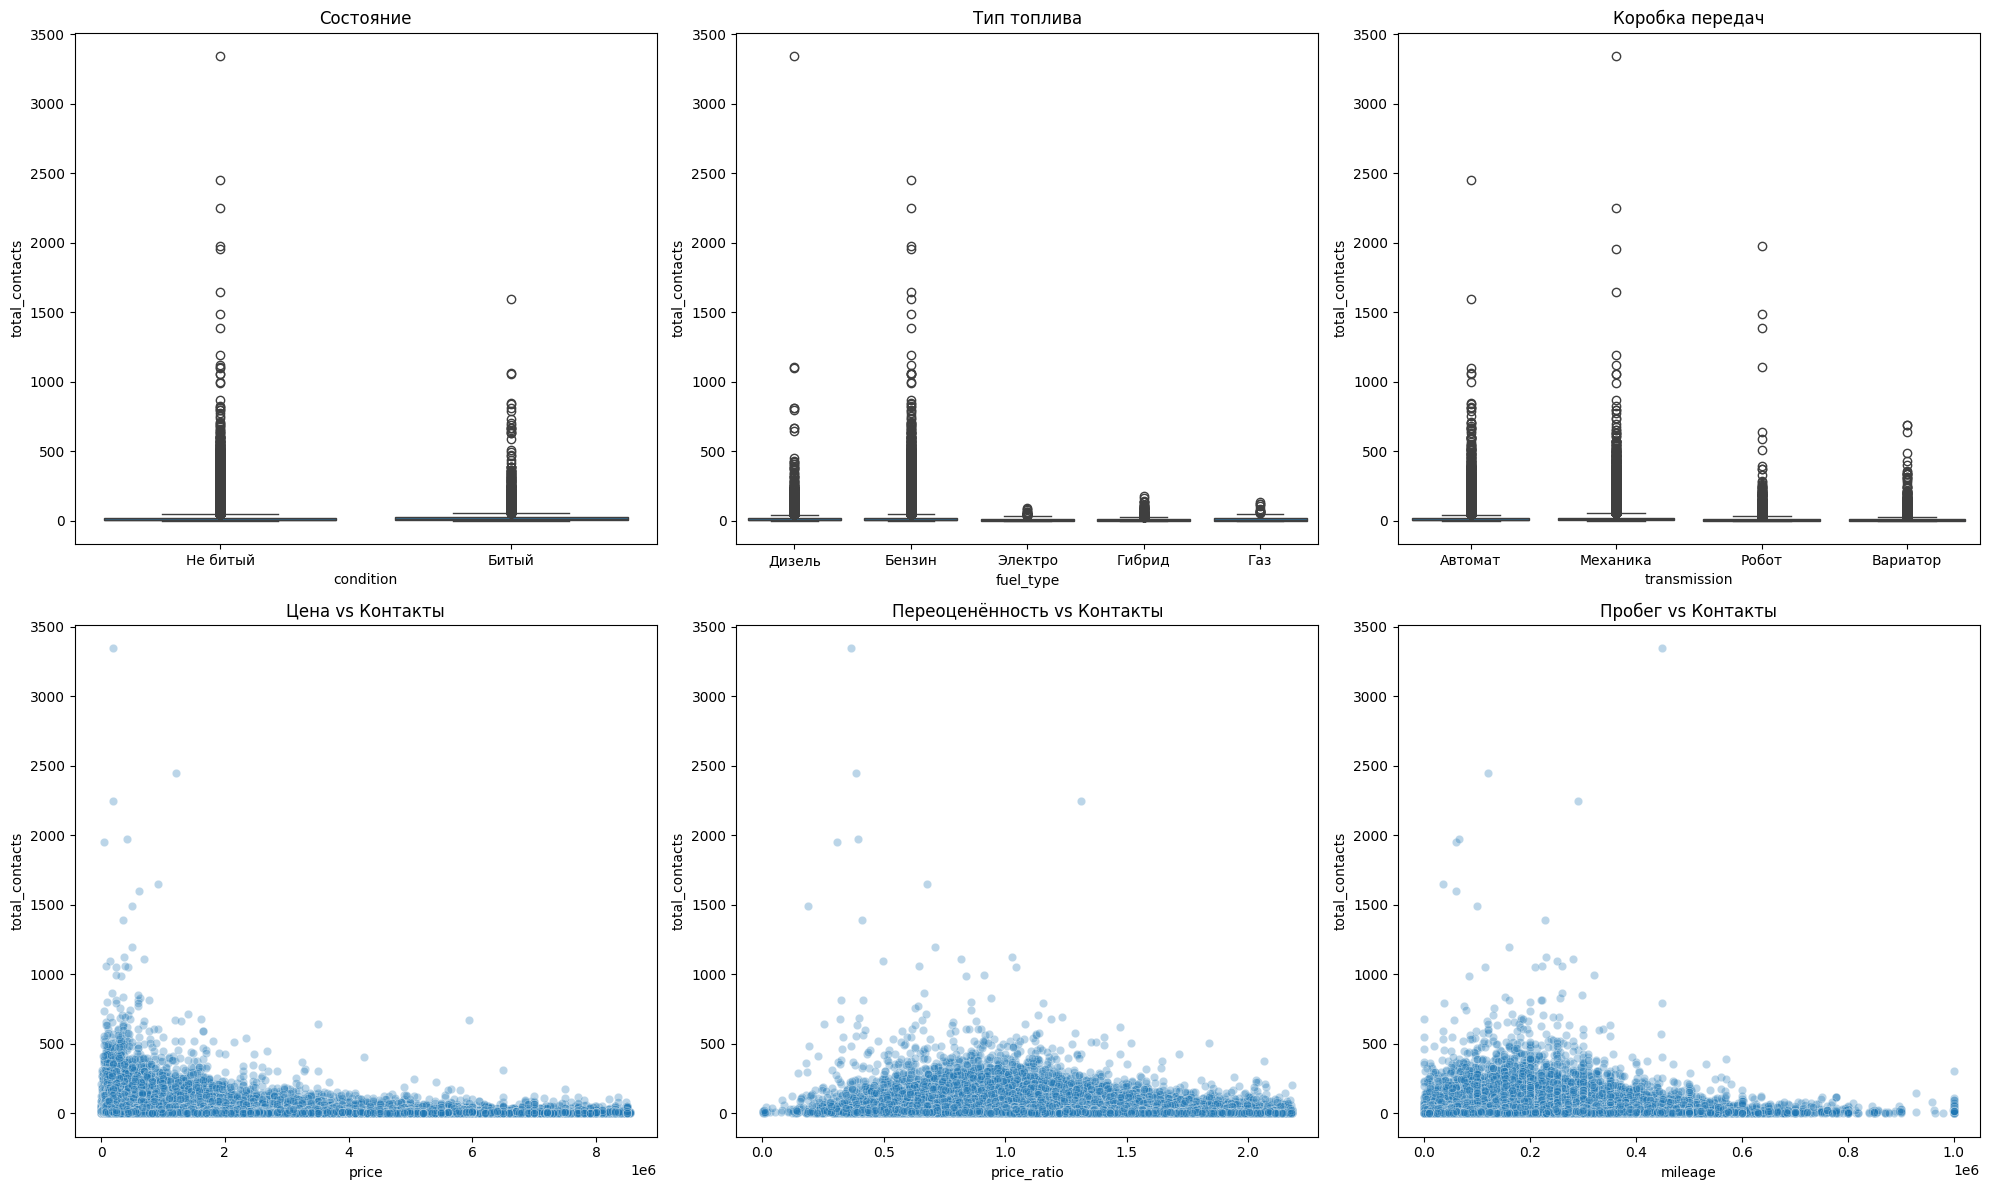

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Верхний ряд — категориальные
sns.boxplot(data=data_full, x="condition", y="total_contacts", ax=axes[0][0])
axes[0][0].set_title("Состояние")

sns.boxplot(data=data_full, x="fuel_type", y="total_contacts", ax=axes[0][1])
axes[0][1].set_title("Тип топлива")

sns.boxplot(data=data_full, x="transmission", y="total_contacts", ax=axes[0][2])
axes[0][2].set_title("Коробка передач")

# Нижний ряд — числовые через scatter
sns.scatterplot(data=data_full, x="price", y="total_contacts", alpha=0.3, ax=axes[1][0])
axes[1][0].set_title("Цена vs Контакты")

sns.scatterplot(data=data_full, x="price_ratio", y="total_contacts", alpha=0.3, ax=axes[1][1])
axes[1][1].set_title("Переоценённость vs Контакты")

sns.scatterplot(data=data_full, x="mileage", y="total_contacts", alpha=0.3, ax=axes[1][2])
axes[1][2].set_title("Пробег vs Контакты")

plt.tight_layout()
plt.show()

Заметим, что Не битые получают больше контантов, также как и: Бензиновые 

144.0


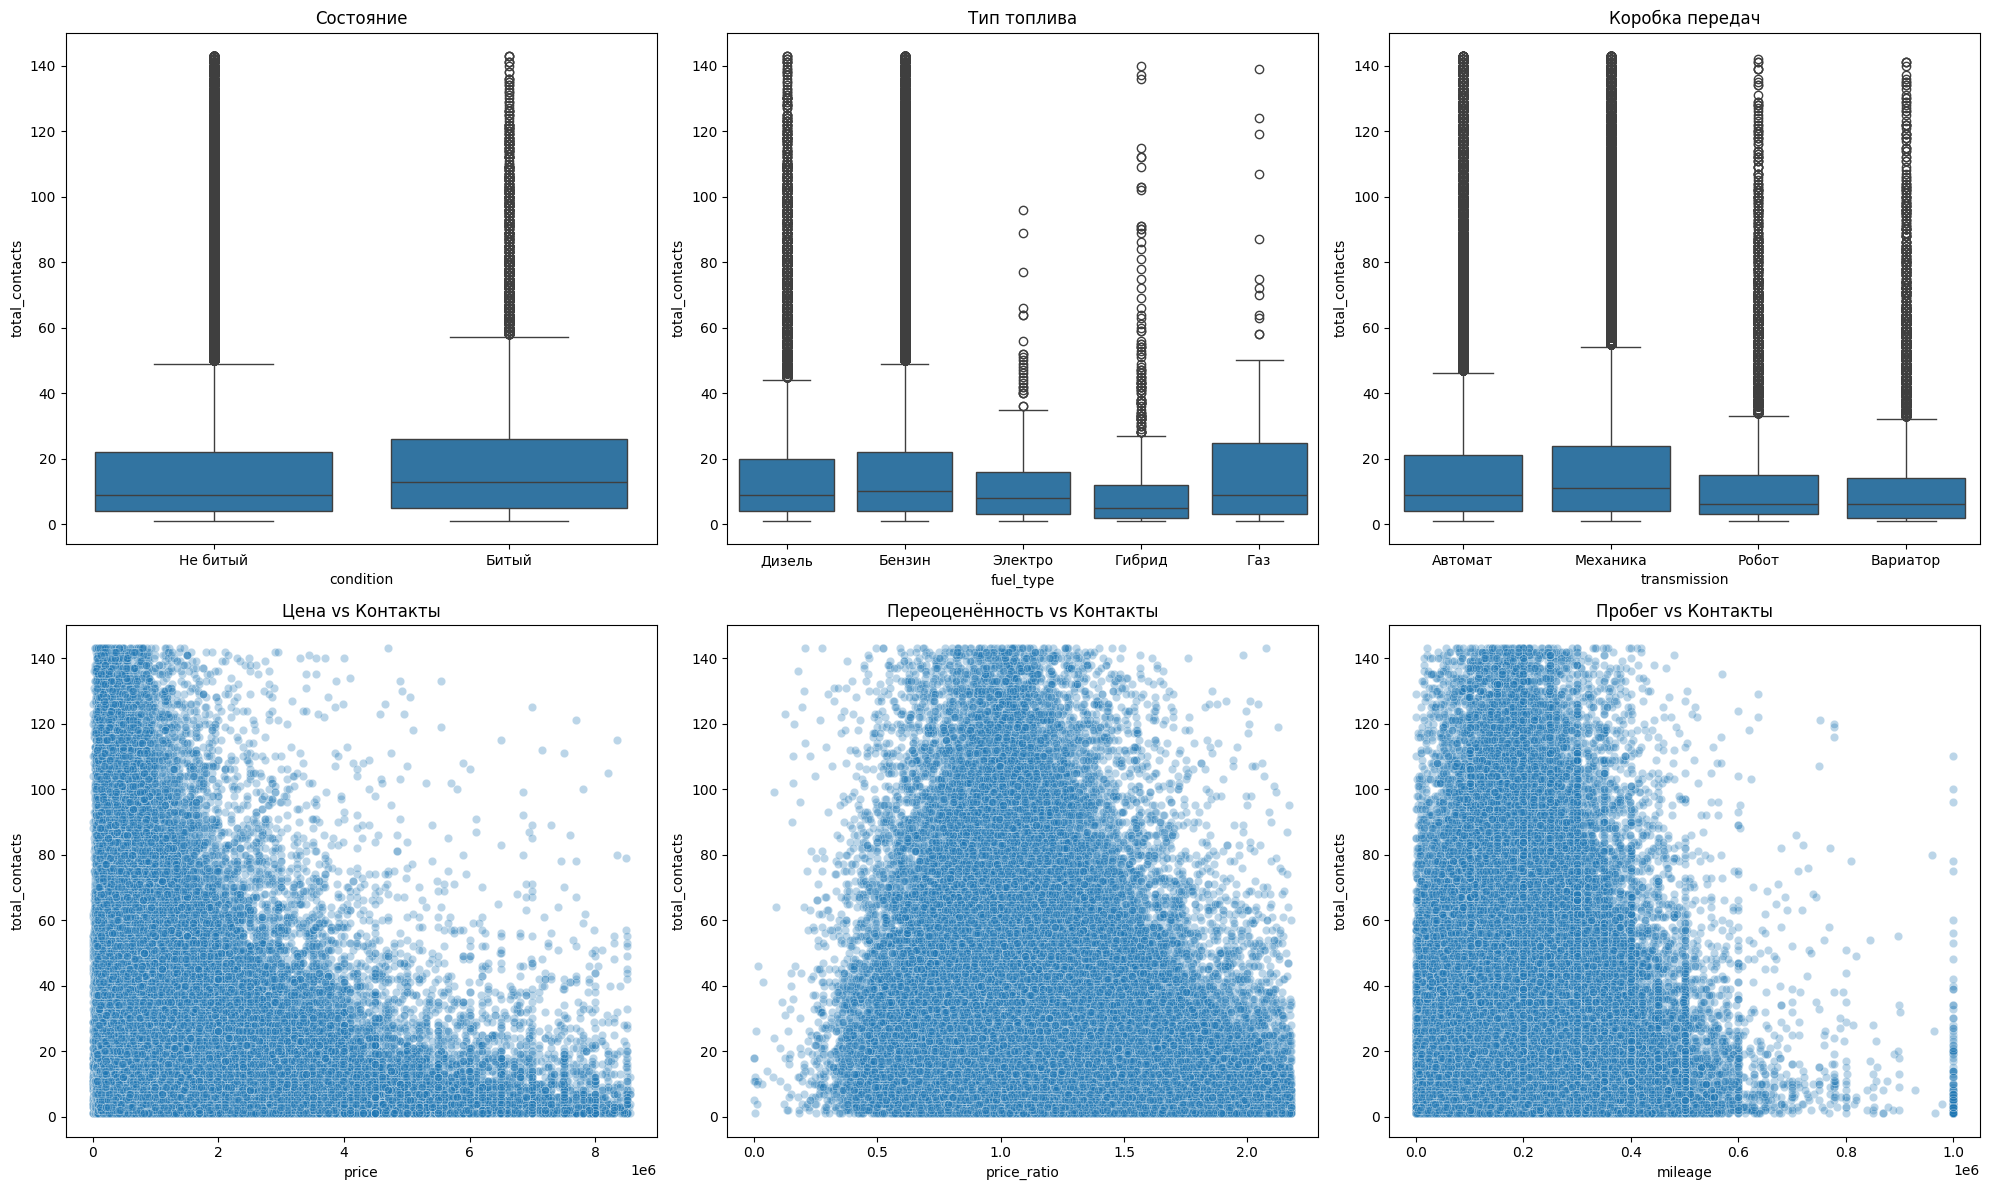

In [31]:
print(data_full["total_contacts"].quantile(0.99))


data_full = data_full[data_full["total_contacts"] < data_full["total_contacts"].quantile(0.99)]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Верхний ряд — категориальные
sns.boxplot(data=data_full, x="condition", y="total_contacts", ax=axes[0][0])
axes[0][0].set_title("Состояние")

sns.boxplot(data=data_full, x="fuel_type", y="total_contacts", ax=axes[0][1])
axes[0][1].set_title("Тип топлива")

sns.boxplot(data=data_full, x="transmission", y="total_contacts", ax=axes[0][2])
axes[0][2].set_title("Коробка передач")

# Нижний ряд — числовые через scatter
sns.scatterplot(data=data_full, x="price", y="total_contacts", alpha=0.3, ax=axes[1][0])
axes[1][0].set_title("Цена vs Контакты")

sns.scatterplot(data=data_full, x="price_ratio", y="total_contacts", alpha=0.3, ax=axes[1][1])
axes[1][1].set_title("Переоценённость vs Контакты")

sns.scatterplot(data=data_full, x="mileage", y="total_contacts", alpha=0.3, ax=axes[1][2])
axes[1][2].set_title("Пробег vs Контакты")

plt.tight_layout()
plt.show()

In [32]:
data_full[data_full["price_ratio"] < 0.4][["price", "imv", "price_ratio", "brand", "condition"]]


,price,imv,price_ratio,brand,condition
252,60000.00,152900.00,0.39,Chevrolet,Не битый
287,600000.00,1758100.00,0.34,ГАЗ,Не битый
1130,80000.00,356500.00,0.22,FIAT,Не битый
1913,280000.00,1189800.00,0.24,Suzuki,Не битый
2194,30000.00,140100.00,0.21,ВАЗ (LADA),Не битый
...,...,...,...,...,...
409412,60000.00,266000.00,0.23,Ford,Не битый
410675,70000.00,204600.00,0.34,Daewoo,Не битый
411992,45000.00,160400.00,0.28,ГАЗ,Не битый
412065,45000.00,115400.00,0.39,ВАЗ (LADA),Не битый


In [33]:
data_full = data_full[
    (data_full["price_ratio"] >= 0.01) | 
    (data_full["condition"] == "Битый")
].copy()

print(data_full["condition"].value_counts())

condition
Не битый    272009
Битый        10207
Name: count, dtype: int64


In [34]:
# Сколько битых в исходном data
print("В data:", data[data["condition"] == "Битый"].shape[0])

# Сколько битых есть в data_cnt (есть ли у них контакты)
битые_ids = data[data["condition"] == "Битый"]["id"]
print("Битых с контактами:", data_cnt[data_cnt["id"].isin(битые_ids)]["id"].nunique())

В data: 12900
Битых с контактами: 10407


Пожалуй, смысла предлагать клиентам продавать на 70% ниже рыночной будет довольно глупо...

In [35]:
data_full["listing_days"] = (
    pd.to_datetime(data_full["close_time"]) - 
    pd.to_datetime(data_full["start_time"])
).dt.days

data_full["listing_days"].describe()


count   282216.00
mean        23.46
std         19.36
min          1.00
25%          7.00
50%         19.00
75%         32.00
max         91.00
Name: listing_days, dtype: float64

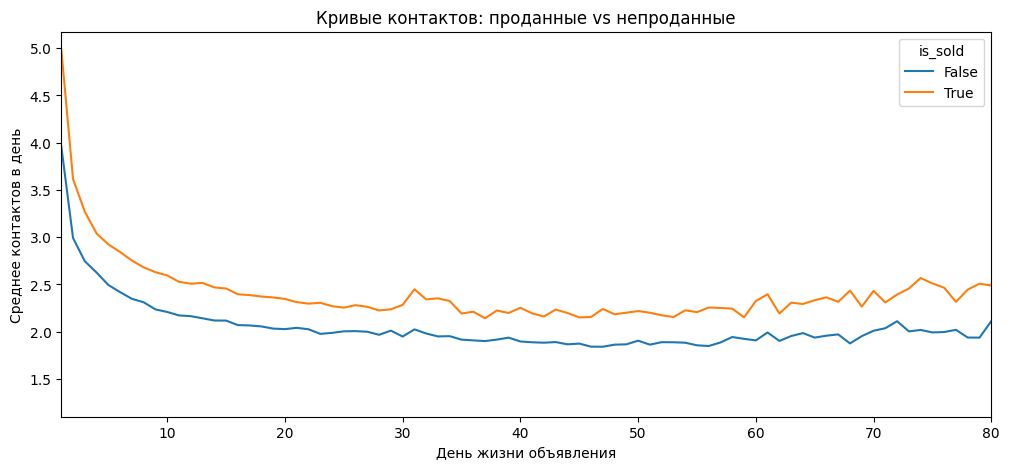

In [36]:
# Добавляем метку — продано или нет
data_full["is_sold"] = data_full["removal_reason"] == "Продано на Avito"

# Присоединяем к контактам
cnt_with_data = data_cnt.merge(
    data_full[["id", "condition", "price_ratio", "is_sold"]], 
    on="id", how="left"
)

# Строим кривые по факту продажи
pivot = cnt_with_data.groupby(
    ["is_sold", "day"]
)["cnt_contacts"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=pivot, x="day", y="cnt_contacts", hue="is_sold")
plt.xlim(1, 80)
plt.title("Кривые контактов: проданные vs непроданные")
plt.xlabel("День жизни объявления")
plt.ylabel("Среднее контактов в день")
plt.show()

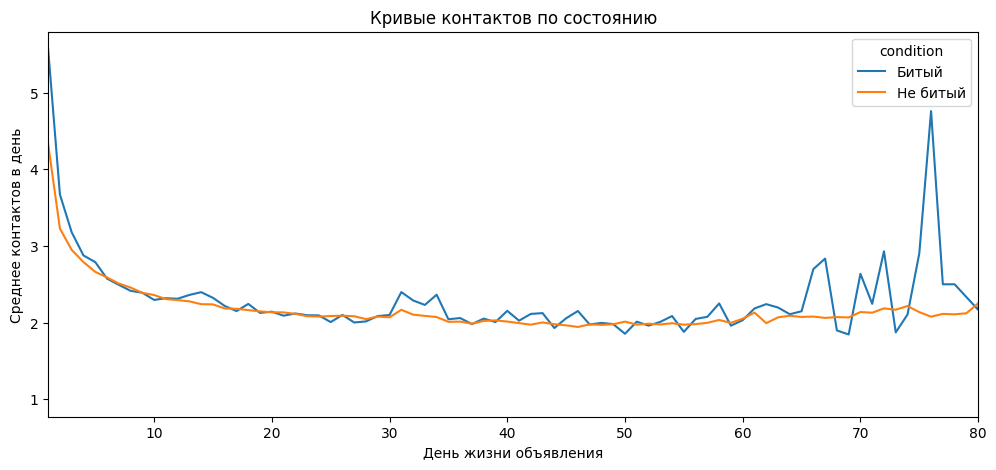

In [37]:
pivot2 = cnt_with_data.groupby(
    ["condition", "day"]
)["cnt_contacts"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=pivot2, x="day", y="cnt_contacts", hue="condition")
plt.xlim(1, 80)
plt.title("Кривые контактов по состоянию")
plt.xlabel("День жизни объявления")
plt.ylabel("Среднее контактов в день")
plt.show()

По данным выше - среднее время жизни объявления - 23 дня, следовательно далее, и тем более за 30-35+ данных настолько мало, что вопрос их учитывания довольно насущен

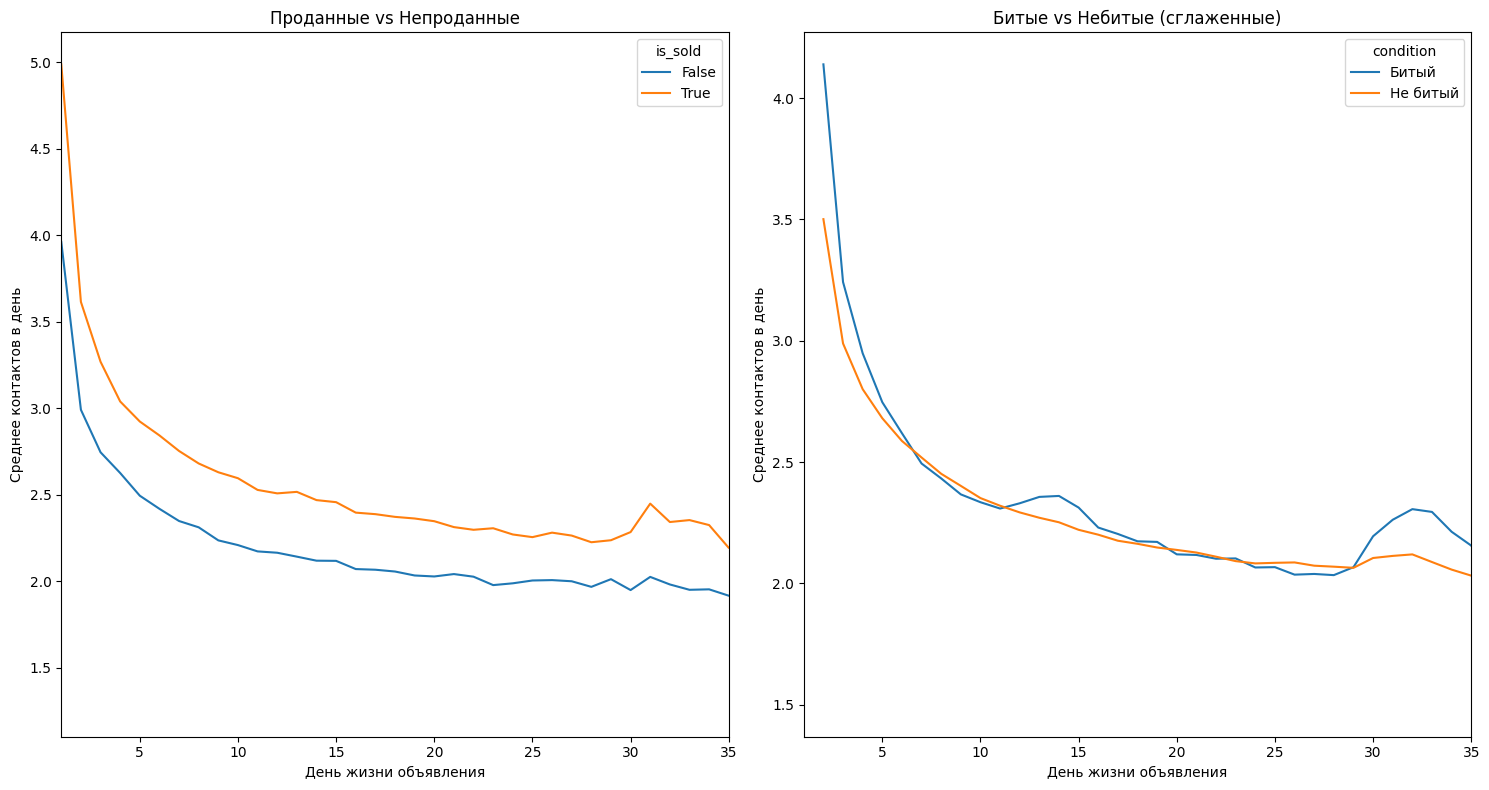

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# График 1 — проданные vs непроданные
pivot1 = cnt_with_data.groupby(
    ["is_sold", "day"]
)["cnt_contacts"].mean().reset_index()

sns.lineplot(data=pivot1, x="day", y="cnt_contacts", hue="is_sold", ax=axes[0])
axes[0].set_xlim(1, 35)
axes[0].set_title("Проданные vs Непроданные")
axes[0].set_xlabel("День жизни объявления")
axes[0].set_ylabel("Среднее контактов в день")

# График 2 — битые vs небитые (сглаженные)
pivot2 = cnt_with_data.groupby(
    ["condition", "day"]
)["cnt_contacts"].mean().reset_index()

pivot2["smooth"] = pivot2.groupby("condition")["cnt_contacts"].transform(
    lambda x: x.rolling(3, center=True).mean()
)

sns.lineplot(data=pivot2, x="day", y="smooth", hue="condition", ax=axes[1])
axes[1].set_xlim(1, 35)
axes[1].set_title("Битые vs Небитые (сглаженные)")
axes[1].set_xlabel("День жизни объявления")
axes[1].set_ylabel("Среднее контактов в день")

plt.tight_layout()
plt.show()

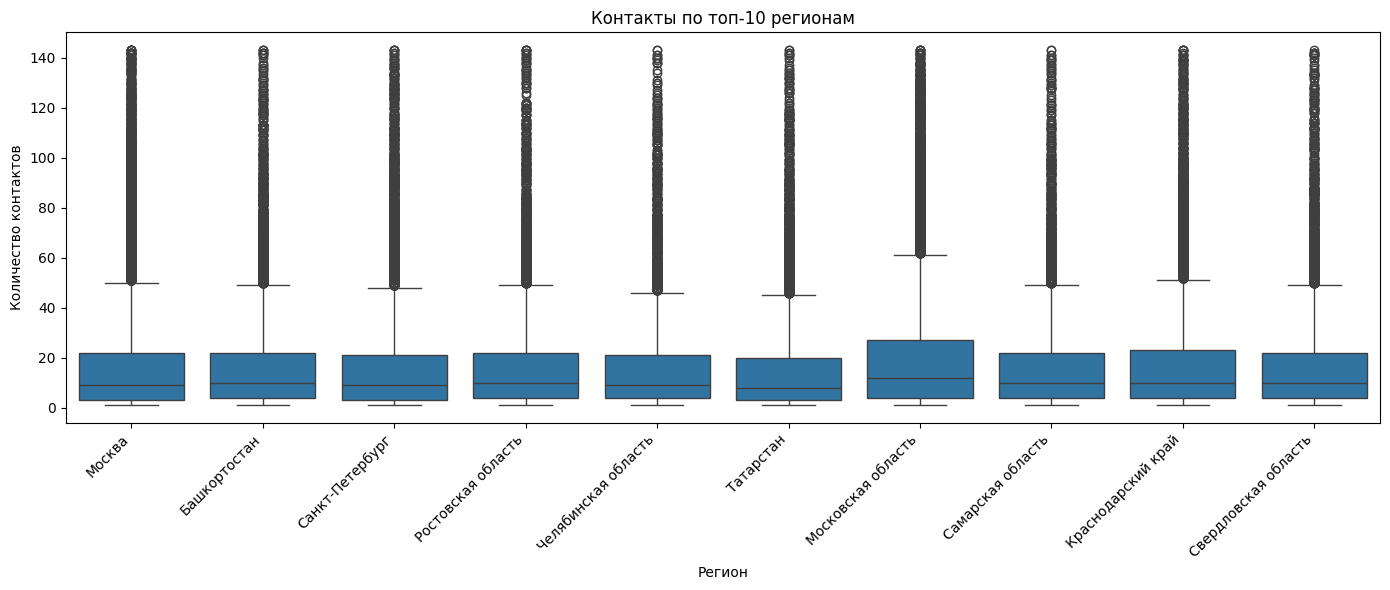

In [39]:
top_regions = data_full["region"].value_counts().head(10).index

regional = data_full[data_full["region"].isin(top_regions)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=regional, x="region", y="total_contacts")
plt.xticks(rotation=45, ha="right")
plt.title("Контакты по топ-10 регионам")
plt.xlabel("Регион")
plt.ylabel("Количество контактов")
plt.tight_layout()
plt.show()


In [40]:
from scipy import stats

results = {}

# 1. Регионы (Kruskal-Wallis — 10 групп)
группы_регионы = [regional[regional["region"] == r]["total_contacts"] for r in top_regions]
stat, p = stats.kruskal(*группы_регионы)
results["Регионы"] = p

# 2. Состояние (Mann-Whitney — 2 группы)
битые = data_full[data_full["condition"] == "Битый"]["total_contacts"]
небитые = data_full[data_full["condition"] == "Не битый"]["total_contacts"]
stat, p = stats.mannwhitneyu(битые, небитые)
results["Состояние (битый vs небитый)"] = p

# 3. Тип топлива (Kruskal-Wallis)
группы_топливо = [data_full[data_full["fuel_type"] == f]["total_contacts"] for f in data_full["fuel_type"].unique()]
stat, p = stats.kruskal(*группы_топливо)
results["Тип топлива"] = p

# 4. Коробка передач (Kruskal-Wallis)
группы_кпп = [data_full[data_full["transmission"] == t]["total_contacts"] for t in data_full["transmission"].unique()]
stat, p = stats.kruskal(*группы_кпп)
results["Коробка передач"] = p

# 5. Проданные vs непроданные (Mann-Whitney)
проданные = data_full[data_full["is_sold"] == True]["total_contacts"]
непроданные = data_full[data_full["is_sold"] == False]["total_contacts"]
stat, p = stats.mannwhitneyu(проданные, непроданные)
results["Проданные vs Непроданные"] = p

# 6. Корреляция цены с контактами (Spearman)
corr, p = stats.spearmanr(data_full["price"], data_full["total_contacts"])
results["Цена vs Контакты (Spearman)"] = p

# 7. Корреляция price_ratio с контактами (Spearman) — исключаем NaN
mask = data_full["price_ratio"].notna()
corr, p = stats.spearmanr(
    data_full.loc[mask, "price_ratio"],
    data_full.loc[mask, "total_contacts"]
)
results["Переоценённость vs Контакты (Spearman)"] = p

# Вывод результатов
print(f"{'Тест':<40} {'p-value':<12} {'Вывод'}")
print("-" * 70)
for name, p in results.items():
    pri = "✅ значимо" if p < 0.05 else "❌ случайно"
    if p < 0.0001:
        p_str = "< 0.0001"
    else:
        p_str = f"{p:.4f}"
    print(f"{name:<40} {p_str:<12} {pri}")

print("-" * 70)
for name, p in results.items():
    pri = "✅ значимо" if p < 0.05 else "❌ случайно"
    print(f"{name:<40} {p:<20.2e} {pri}")

Тест                                     p-value      Вывод
----------------------------------------------------------------------
Регионы                                  < 0.0001     ✅ значимо
Состояние (битый vs небитый)             < 0.0001     ✅ значимо
Тип топлива                              < 0.0001     ✅ значимо
Коробка передач                          < 0.0001     ✅ значимо
Проданные vs Непроданные                 < 0.0001     ✅ значимо
Цена vs Контакты (Spearman)              < 0.0001     ✅ значимо
Переоценённость vs Контакты (Spearman)   < 0.0001     ✅ значимо
----------------------------------------------------------------------
Регионы                                  4.64e-139            ✅ значимо
Состояние (битый vs небитый)             3.73e-90             ✅ значимо
Тип топлива                              3.09e-58             ✅ значимо
Коробка передач                          0.00e+00             ✅ значимо
Проданные vs Непроданные                 0.00e+00             

In [41]:
data_full["sold_status"] = "Неизвестно"  # NaN в removal_reason

data_full.loc[
    data_full["removal_reason"] == "Продано на Avito", "sold_status"
] = "Продано на Авито"

data_full.loc[
    data_full["removal_reason"] == "Продано где-то ещё", "sold_status"
] = "Продано elsewhere"

data_full.loc[
    data_full["removal_reason"] == "Другая причина", "sold_status"
] = "Другая причина"

data_full.loc[
    data_full["removal_reason"] == "Нет ответа", "sold_status"
] = "Нет ответа"

print(data_full["sold_status"].value_counts())

sold_status
Продано на Авито     96835
Другая причина       85523
Нет ответа           41245
Неизвестно           29358
Продано elsewhere    29255
Name: count, dtype: int64


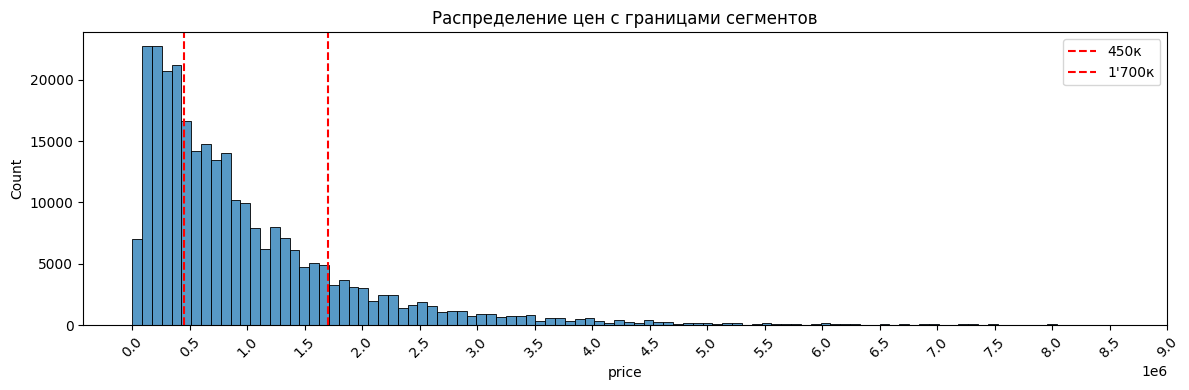

In [42]:
plt.figure(figsize=(12, 4))
sns.histplot(data_full["price"], bins=100)
plt.axvline(450_000, color="red", linestyle="--", label="450к")
plt.axvline(1_700_000, color="red", linestyle="--", label="1'700к")
#plt.axvline(450_000, color="red", linestyle="--", label="700к")
plt.title("Распределение цен с границами сегментов")
plt.legend()
plt.xticks(range(0, 9_000_001, 500_000), rotation=45)  # каждые 500к
plt.tight_layout()
plt.show()

In [43]:
data_full["segment_price"] = "Средний класс"
data_full.loc[data_full["price"] < 450_000, "segment_price"] = "Бюджетные"
data_full.loc[data_full["price"] > 1_700_000, "segment_price"] = "Премиум"
data_full.loc[data_full["price_ratio"] > 1.2, "segment_price"] = "Переоценённые"

print(data_full["segment_price"].value_counts())


segment_price
Средний класс    96024
Переоценённые    88135
Бюджетные        62091
Премиум          35966
Name: count, dtype: int64


In [44]:
print("=== Статистика по ценовым сегментам ===")
print(data_full.groupby("segment_price")[
    ["total_contacts", "listing_days", "price_ratio"]
].agg(["median", "mean"]).round(2))


=== Статистика по ценовым сегментам ===
              total_contacts       listing_days       price_ratio     
                      median  mean       median  mean      median mean
segment_price                                                         
Бюджетные              16.00 25.01        11.00 17.49        0.99 0.95
Переоценённые           8.00 14.90        24.00 26.78        1.33 1.40
Премиум                 7.00 12.77        25.00 27.68        1.07 1.06
Средний класс           9.00 16.17        18.00 22.70        1.07 1.05


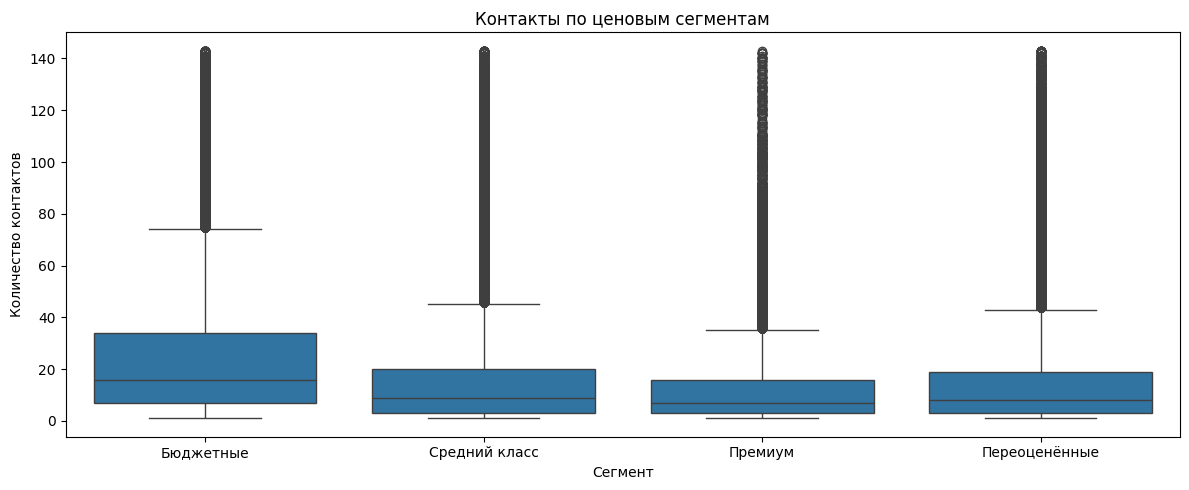

In [45]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=data_full, x="segment_price", y="total_contacts",
            order=["Бюджетные", "Средний класс", "Премиум", "Переоценённые"])
plt.title("Контакты по ценовым сегментам")
plt.xlabel("Сегмент")
plt.ylabel("Количество контактов")
plt.tight_layout()
plt.show()

In [46]:
sold_by_segment = data_full[data_full["is_sold"] == True].groupby(
    "segment_price"
)["listing_days"].median()

print(sold_by_segment)

segment_price
Бюджетные        9.00
Переоценённые   17.00
Премиум         18.00
Средний класс   13.00
Name: listing_days, dtype: float64


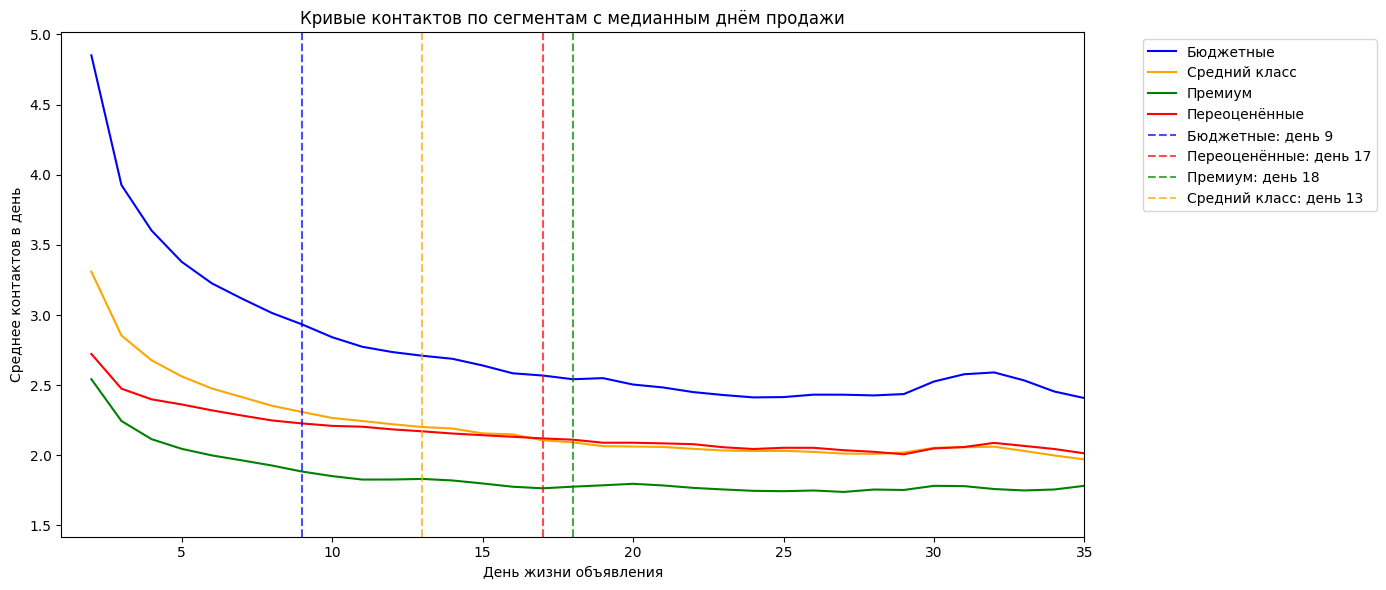

In [47]:
cnt_with_segments = data_cnt.merge(
    data_full[["id", "segment_price"]],
    on="id", how="left"
).dropna(subset=["segment_price"])

pivot = cnt_with_segments.groupby(
    ["segment_price", "day"]
)["cnt_contacts"].mean().reset_index()

pivot["smooth"] = pivot.groupby("segment_price")["cnt_contacts"].transform(
    lambda x: x.rolling(3, center=True).mean()
)

# Цвета совпадают с линиями сегментов
colors = {
    "Бюджетные": "blue",
    "Средний класс": "orange",
    "Премиум": "green",
    "Переоценённые": "red"
}

plt.figure(figsize=(14, 6))
sns.lineplot(data=pivot, x="day", y="smooth", hue="segment_price",
             hue_order=["Бюджетные", "Средний класс", "Премиум", "Переоценённые"],
             palette=colors)

# Вертикальные линии — медианный день продажи
for segment, day in sold_by_segment.items():
    plt.axvline(x=day, color=colors[segment], linestyle="--", alpha=0.7,
                label=f"{segment}: день {int(day)}")

plt.xlim(1, 35)
plt.title("Кривые контактов по сегментам с медианным днём продажи")
plt.xlabel("День жизни объявления")
plt.ylabel("Среднее контактов в день")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#Пожалуй, основа сделана - у нас есть основные данные. Думаю, стоит посмотреть и поискать более неочевидные закономерности

In [48]:
display(data_full)
print()
data_full.describe()

,id,start_time,close_time,brand,model,generation,body_type,year,mileage,price,...,total_contacts,active_days,first_day_contacts,max_daily,avg_daily,price_ratio,listing_days,is_sold,sold_status,segment_price
0,263951,2024-07-20 16:51:47.744669,2024-08-14 20:35:34.353783,Kia,Sorento,I (2002—2006),Внедорожник,2002,290000,630000.00,...,69.00,20.00,2.00,9.00,3.45,1.15,25,True,Продано на Авито,Средний класс
1,223634,2024-07-17 15:35:34.290251,2024-07-19 11:38:22.750530,Kia,Sorento,II рестайлинг (2012—2021),Внедорожник,2014,131000,1530000.00,...,1.00,1.00,1.00,1.00,1.00,0.89,1,False,Неизвестно,Средний класс
2,282105,2024-07-22 10:19:17.534577,2024-07-31 18:29:03.218218,Toyota,Land Cruiser Prado,150 (2009—2013),Внедорожник,2012,250000,2749000.00,...,4.00,2.00,2.00,2.00,2.00,0.95,9,False,Другая причина,Премиум
3,108565,2024-07-08 22:11:23.788182,2024-09-07 10:38:38.021999,ВАЗ (LADA),Granta,I (2011—2018),Лифтбек,2016,150000,529000.00,...,5.00,4.00,2.00,2.00,1.25,1.07,60,False,Неизвестно,Средний класс
4,228568,2024-07-17 20:49:44.749832,2024-09-04 08:19:21.514770,Volkswagen,Polo,V (2009—2015),Седан,2013,213433,685000.00,...,67.00,25.00,1.00,13.00,2.68,1.15,48,True,Продано на Авито,Средний класс
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412792,302584,2024-07-23 17:36:29.299255,2024-09-21 19:21:15.007461,Ford,Escape,I (2000—2004),Внедорожник,2001,300001,250000.00,...,25.00,18.00,1.00,4.00,1.39,0.83,60,False,Продано elsewhere,Бюджетные
412793,382704,2024-07-29 20:15:59.154296,2024-09-05 20:30:52.002824,Opel,Astra,H рестайлинг (2006—2014),Хетчбэк,2008,234200,550000.00,...,19.00,12.00,1.00,4.00,1.58,1.24,38,True,Продано на Авито,Переоценённые
412794,402543,2024-07-31 12:18:24.989677,2024-08-05 20:11:38.068717,ВАЗ (LADA),Priora,I (2007—2013),Универсал,2009,210000,487000.00,...,12.00,3.00,3.00,8.00,4.00,1.43,5,True,Продано на Авито,Переоценённые
412795,114672,2024-07-09 13:25:42.008523,2024-08-27 20:03:12.536420,Hyundai,Sonata,IV рестайлинг (2001—2012),Седан,2002,266715,429990.00,...,2.00,2.00,1.00,1.00,1.00,1.43,49,False,Нет ответа,Переоценённые


,id,year,mileage,price,imv,rating,reviews,total_contacts,active_days,first_day_contacts,max_daily,avg_daily,price_ratio,listing_days
count,282216.00,282216.00,282216.00,282216.00,272232.00,210056.00,210056.00,282216.00,282216.00,282216.00,282216.00,282216.00,272232.00,282216.00
mean,208039.56,2010.39,174638.11,1000689.86,924742.46,4.64,208.64,17.29,6.81,2.77,5.01,2.78,1.14,23.46
std,118673.57,6.93,96279.60,1030579.54,968262.10,0.67,797.59,21.36,6.68,4.32,5.77,3.87,0.24,19.36
min,2.00,1957.00,1.00,1.00,27800.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.01,1.00
25%,105445.50,2007.00,106000.00,330000.00,296100.00,4.55,3.00,4.00,2.00,1.00,2.00,1.20,1.02,7.00
50%,208715.50,2011.00,167800.00,690000.00,630600.00,4.91,12.00,9.00,5.00,1.00,3.00,1.80,1.12,19.00
75%,310845.25,2015.00,229000.00,1300000.00,1196900.00,5.00,68.00,22.00,9.00,3.00,6.00,2.84,1.25,32.00
max,412801.00,2026.00,1000000.00,8550000.00,19917000.00,5.00,9901.00,143.00,60.00,143.00,143.00,143.00,2.18,91.00


In [49]:
# Цвет
print(data_full.groupby("color")["total_contacts"].median().sort_values(ascending=False))
# Привод
print("_"*70)
print(data_full.groupby("drive")["total_contacts"].median().sort_values(ascending=False))
# Тип кузова


color
Бордовый     12.00
Зелёный      12.00
Золотой      11.00
Чёрный       10.00
Голубой      10.00
Жёлтый       10.00
Фиолетовый   10.00
Серебряный   10.00
Пурпурный    10.00
Синий        10.00
Бежевый       9.00
Белый         9.00
Красный       9.00
Серый         9.00
Коричневый    8.00
Розовый       8.00
Оранжевый     8.00
Name: total_contacts, dtype: float64
______________________________________________________________________
drive
Задний     13.00
Передний   10.00
Полный      8.00
Name: total_contacts, dtype: float64


Довольно неожиданны результаты по цвету - всё таки, обычно более нейтральные цвета в "почете"

In [50]:
print("_"*70)
print(data_full.groupby("body_type")["total_contacts"].median().sort_values(ascending=False))

______________________________________________________________________
body_type
Купе           12.00
Фургон         12.00
Микроавтобус   12.00
Седан          11.00
Пикап          10.00
Хетчбэк        10.00
Минивэн        10.00
Универсал       9.00
Кабриолет       9.00
Лифтбек         8.00
Внедорожник     7.00
Name: total_contacts, dtype: float64


In [51]:
print("Топ кузовов по количеству объявлений:")
print(data_full["body_type"].value_counts().head(5))

print("\nМедиана контактов по кузовам:")
print(data_full.groupby("body_type")["total_contacts"].median().sort_values(ascending=False))

Топ кузовов по количеству объявлений:
body_type
Седан          116856
Внедорожник     65589
Хетчбэк         54618
Универсал       15460
Лифтбек          9287
Name: count, dtype: int64

Медиана контактов по кузовам:
body_type
Купе           12.00
Фургон         12.00
Микроавтобус   12.00
Седан          11.00
Пикап          10.00
Хетчбэк        10.00
Минивэн        10.00
Универсал       9.00
Кабриолет       9.00
Лифтбек         8.00
Внедорожник     7.00
Name: total_contacts, dtype: float64


«Продавцы внедорожников сталкиваются с парадоксом — это второй по популярности тип кузова, но каждое объявление получает вдвое меньше контактов чем купе или фургон. Причина — высокая конкуренция внутри сегмента. Именно владельцам внедорожников VAS принесёт наибольшую пользу — он поможет выделиться на фоне конкурентов»

In [52]:
print(data_full["brand"].value_counts().head(25))

brand
ВАЗ (LADA)       74226
Kia              18301
Hyundai          17796
Toyota           15937
Volkswagen       13211
Chevrolet        12112
Nissan           11885
Ford             11416
Renault          10725
BMW               7249
Mercedes-Benz     7226
Mitsubishi        7223
Skoda             6731
ГАЗ               6713
Opel              6485
Mazda             5977
Daewoo            4806
Audi              4764
Honda             4218
Peugeot           3092
УАЗ               3011
Chery             2761
Geely             2157
Lexus             1752
Citroen           1739
Name: count, dtype: int64


In [53]:
top_brands = data_full["brand"].value_counts().head(25).index.tolist()

cnt_with_brands = data_cnt.merge(
    data_full[["id", "brand", "listing_days", "is_sold"]],
    on="id", how="left"
).dropna(subset=["brand"])

cnt_top = cnt_with_brands[cnt_with_brands["brand"].isin(top_brands)]

# Медианный день продажи для каждого бренда
sold_by_brand = data_full[
    (data_full["is_sold"] == True) & 
    (data_full["brand"].isin(top_brands))
].groupby("brand")["listing_days"].median().sort_values()

print(sold_by_brand)

brand
Daewoo          11.00
ВАЗ (LADA)      11.00
Ford            13.00
Chevrolet       13.00
Mazda           13.00
Chery           13.00
Renault         13.00
Citroen         14.00
Nissan          14.00
Honda           14.00
Kia             14.00
Hyundai         14.00
Mitsubishi      14.00
Peugeot         14.00
Geely           14.00
Audi            14.00
Volkswagen      14.00
Opel            14.00
Mercedes-Benz   15.00
Skoda           15.00
Toyota          15.00
ГАЗ             16.00
УАЗ             16.00
BMW             19.00
Lexus           19.00
Name: listing_days, dtype: float64


In [54]:
country_map = {
    "ВАЗ (LADA)": "Россия",
    "ГАЗ": "Россия",
    "УАЗ": "Россия",
    "Kia": "Корея",
    "Hyundai": "Корея",
    "Daewoo": "Корея",
    "Chery": "Китай",
    "Geely": "Китай",
    "Toyota": "Япония",
    "Nissan": "Япония",
    "Mitsubishi": "Япония",
    "Mazda": "Япония",
    "Honda": "Япония",
    "Lexus": "Япония",
    "Volkswagen": "Германия",
    "BMW": "Германия",
    "Mercedes-Benz": "Германия",
    "Audi": "Германия",
    "Opel": "Германия",
    "Skoda": "Германия",
    "Ford": "США",
    "Chevrolet": "США",
    "Renault": "Франция",
    "Peugeot": "Франция",
    "Citroen": "Франция",
}

data_full["country"] = data_full["brand"].map(country_map)

print(data_full["country"].value_counts())

country
Россия      83950
Япония      46992
Германия    45666
Корея       40903
США         23528
Франция     15556
Китай        4918
Name: count, dtype: int64


In [55]:
print("=== Медиана контактов по стране ===")
print(data_full.groupby("country")["total_contacts"].median().sort_values(ascending=False))

print("\n=== Медиана дней продажи по стране ===")
print(data_full[data_full["is_sold"] == True].groupby("country")["listing_days"].median().sort_values())

=== Медиана контактов по стране ===
country
Россия     12.00
США         9.00
Германия    9.00
Япония      9.00
Корея       8.00
Франция     8.00
Китай       6.00
Name: total_contacts, dtype: float64

=== Медиана дней продажи по стране ===
country
Россия     11.00
Китай      13.00
Франция    13.00
США        13.00
Япония     14.00
Корея      14.00
Германия   15.00
Name: listing_days, dtype: float64


In [56]:
print("=== Медиана цены по стране ===")
print(data_full.groupby("country")["price"].median().sort_values(ascending=False))

print("\n=== Медиана price_ratio по стране ===")
print(data_full.groupby("country")["price_ratio"].median().sort_values(ascending=False))

=== Медиана цены по стране ===
country
Германия   1100000.00
Корея      1050000.00
Япония      950000.00
Китай       819888.50
Франция     665000.00
США         595000.00
Россия      310000.00
Name: price, dtype: float64

=== Медиана price_ratio по стране ===
country
Россия     1.14
США        1.13
Германия   1.12
Япония     1.11
Франция    1.11
Корея      1.10
Китай      1.07
Name: price_ratio, dtype: float64


Ключевые инсайты
Россия дешевле всех в 3.5 раза - вот главная причина высокой ликвидности. Не потому что «отечественное лучше», а просто цена доступнее.
Китай - парадокс - относительно недорогие (820к) но наименее популярные (6 контактов). Скорее всего недоверие к бренду перевешивает цену.
Price_ratio везде выше 1.0 - продавцы всех стран переоценивают авто. Россия переоценивает больше всех (1.14) но всё равно продаёт быстрее - потому что абсолютная цена низкая.

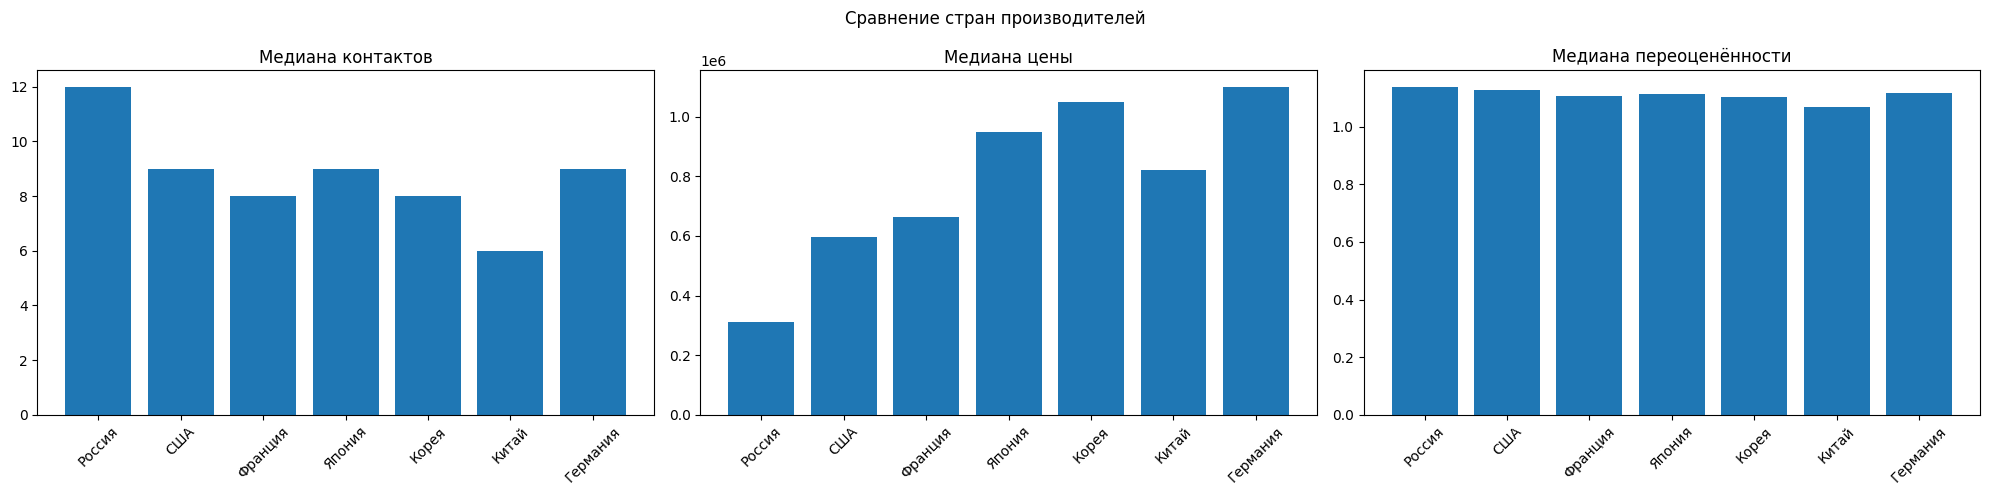

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

order = ["Россия", "США", "Франция", "Япония", "Корея", "Китай", "Германия"]

медианы_контакты = data_full.groupby("country")["total_contacts"].median().reindex(order)
медианы_цена = data_full.groupby("country")["price"].median().reindex(order)
медианы_ratio = data_full.groupby("country")["price_ratio"].median().reindex(order)

axes[0].bar(order, медианы_контакты)
axes[0].set_title("Медиана контактов")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(order, медианы_цена)
axes[1].set_title("Медиана цены")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(order, медианы_ratio)
axes[2].set_title("Медиана переоценённости")
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Сравнение стран производителей")
plt.tight_layout()
plt.show()

In [58]:
data_full["age"] = pd.to_datetime(data_full["start_time"]).dt.year - data_full["year"]

data_full["age_group"] = "Средний (7-15 лет)"
data_full.loc[data_full["age"] <= 3, "age_group"] = "Новый (до 3 лет)"
data_full.loc[data_full["age"].between(4, 7), "age_group"] = "Свежий (4-7 лет)"
data_full.loc[data_full["age"] > 15, "age_group"] = "Старый (15+ лет)"

print(data_full["age_group"].value_counts())
print("\nМедиана контактов по возрасту:")
print(data_full.groupby("age_group")["total_contacts"].median().sort_values(ascending=False))

print("\nМедиана цены по возрасту:")
print(data_full.groupby("age_group")["price"].median().sort_values())

age_group
Средний (7-15 лет)    112812
Старый (15+ лет)      110955
Свежий (4-7 лет)       40992
Новый (до 3 лет)       17457
Name: count, dtype: int64

Медиана контактов по возрасту:
age_group
Старый (15+ лет)     12.00
Средний (7-15 лет)    9.00
Свежий (4-7 лет)      7.00
Новый (до 3 лет)      6.00
Name: total_contacts, dtype: float64

Медиана цены по возрасту:
age_group
Старый (15+ лет)      320000.00
Средний (7-15 лет)    819000.00
Свежий (4-7 лет)     1599229.00
Новый (до 3 лет)     1999000.00
Name: price, dtype: float64


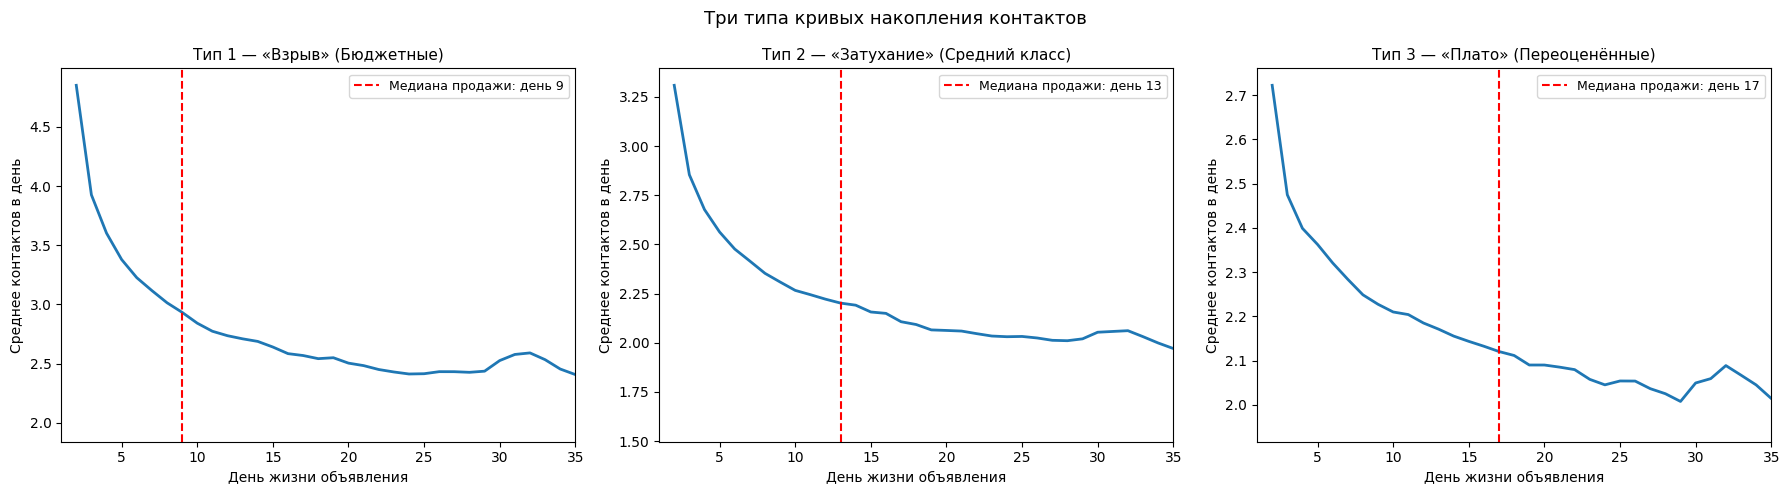

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

сегменты = {
    "Тип 1 — «Взрыв» (Бюджетные)": "Бюджетные",
    "Тип 2 — «Затухание» (Средний класс)": "Средний класс",
    "Тип 3 — «Плато» (Переоценённые)": "Переоценённые"
}

for ax, (title, segment) in zip(axes, сегменты.items()):
    данные = pivot[pivot["segment_price"] == segment]
    ax.plot(данные["day"], данные["smooth"], linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(1, 35)
    ax.set_xlabel("День жизни объявления")
    ax.set_ylabel("Среднее контактов в день")
    ax.axvline(
        x=sold_by_segment[segment],
        color="red", linestyle="--",
        label=f"Медиана продажи: день {int(sold_by_segment[segment])}"
    )
    ax.legend(fontsize=9)

plt.suptitle("Три типа кривых накопления контактов", fontsize=13)
plt.tight_layout()
plt.show()

In [60]:
print("=== Коробка передач ===")
print(data_full.groupby("transmission")[["total_contacts", "price", "listing_days"]].median().sort_values("total_contacts", ascending=False))

print("\n=== Тип топлива ===")
print(data_full.groupby("fuel_type")[["total_contacts", "price", "listing_days"]].median().sort_values("total_contacts", ascending=False))

=== Коробка передач ===
              total_contacts      price  listing_days
transmission                                         
Механика               11.00  410000.00         17.00
Автомат                 9.00 1250000.00         21.00
Вариатор                6.00 1400000.00         24.00
Робот                   6.00 1499000.00         24.00

=== Тип топлива ===
           total_contacts      price  listing_days
fuel_type                                         
Бензин              10.00  650000.00         18.00
Газ                  9.00 1150000.00         30.00
Дизель               9.00 1670000.00         24.00
Электро              8.00 3650000.00         30.00
Гибрид               5.00 1640000.00         30.00


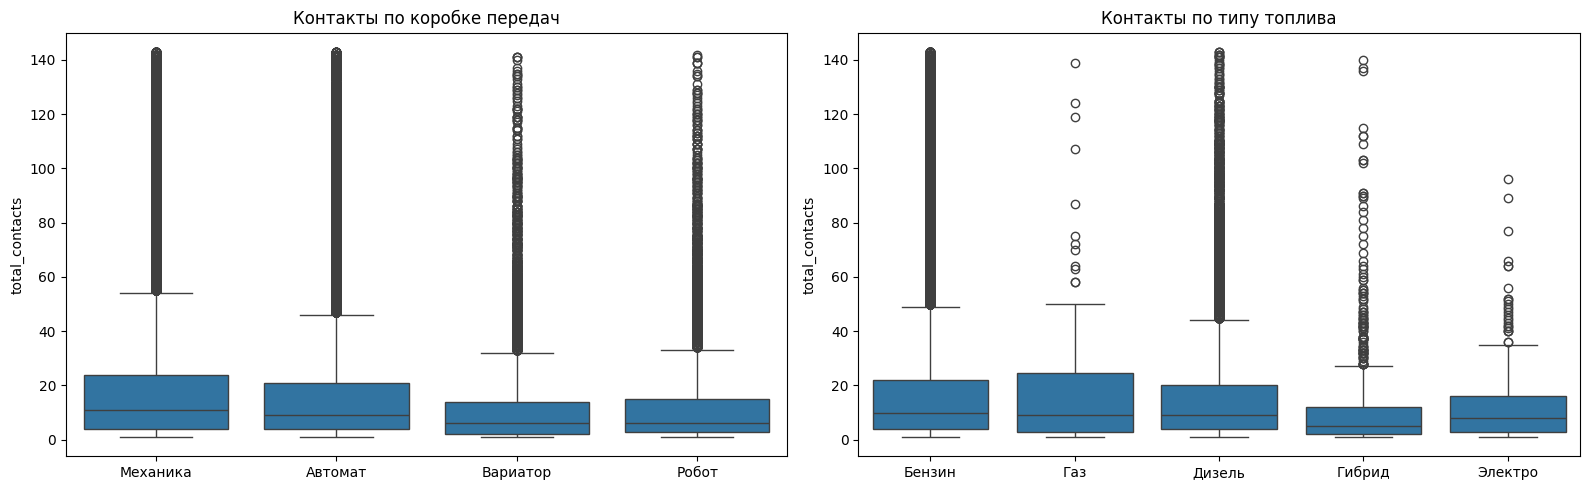

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=data_full, x="transmission", y="total_contacts",
            order=["Механика", "Автомат", "Вариатор", "Робот"], ax=axes[0])
axes[0].set_title("Контакты по коробке передач")
axes[0].set_xlabel("")

sns.boxplot(data=data_full, x="fuel_type", y="total_contacts",
            order=["Бензин", "Газ", "Дизель", "Гибрид", "Электро"], ax=axes[1])
axes[1].set_title("Контакты по типу топлива")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

In [62]:
print("=== Рейтинг ===")
print(data_full.groupby(pd.cut(data_full["rating"], bins=[0,3,4,4.5,5]))["total_contacts"].median())

print("\n=== Отзывы ===")
print(data_full.groupby(pd.cut(data_full["reviews"], bins=[0,5,20,100,10000]))["total_contacts"].median())

=== Рейтинг ===
rating
(0.0, 3.0]   13.00
(3.0, 4.0]    9.00
(4.0, 4.5]    7.00
(4.5, 5.0]    9.00
Name: total_contacts, dtype: float64

=== Отзывы ===
reviews
(0, 5]         12.00
(5, 20]        12.00
(20, 100]       9.00
(100, 10000]    4.00
Name: total_contacts, dtype: float64


In [63]:
print(data_full.groupby(pd.cut(data_full["rating"], bins=[0,3,4,4.5,5]))["price"].median())

rating
(0.0, 3.0]   500000.00
(3.0, 4.0]   670000.00
(4.0, 4.5]   830000.00
(4.5, 5.0]   750000.00
Name: price, dtype: float64


Рейтинг продавца не влияет на ликвидность напрямую — влияет через цену. Продавцы с низким рейтингом компенсируют недоверие скидкой, что и приводит к большему числу контактов

#VAS рекомендации строятся на простой логике:

Если контакты упали до плато до медианного дня продажи — объявление рискует зависнуть. VAS подключать за 2-3 дня до этого момента.

In [64]:
brand_stats = data_full[data_full["is_sold"] == True].groupby(
    ["brand", "condition"]
)["listing_days"].median().reset_index()

brand_stats.columns = ["brand", "condition", "median_sold_day"]

contacts = data_full.groupby(
    ["brand", "condition"]
)["total_contacts"].median().reset_index()

brand_stats = brand_stats.merge(contacts, on=["brand", "condition"])
brand_stats = brand_stats[brand_stats["brand"].isin(top_brands)]

print(brand_stats.sort_values(["median_sold_day", "brand"]))

             brand condition  median_sold_day  total_contacts
117        Peugeot     Битый             7.50            8.00
31          Daewoo     Битый             8.00           14.00
49            Ford     Битый             9.00           11.00
168     ВАЗ (LADA)     Битый             9.00           14.00
27         Citroen     Битый             9.50            9.00
153         Toyota     Битый            10.00           13.00
32          Daewoo  Не битый            11.00           13.00
88             Kia     Битый            11.00           13.00
110         Nissan     Битый            11.00           11.00
155     Volkswagen     Битый            11.00           13.00
169     ВАЗ (LADA)  Не битый            11.00           12.00
3             Audi     Битый            11.50           12.00
70         Hyundai     Битый            11.50           11.00
20           Chery     Битый            12.00            8.50
23       Chevrolet     Битый            12.00           10.00
66      

In [65]:
vas_days = {}

for _, row in brand_stats.iterrows():
    brand = row["brand"]
    condition = row["condition"]
    sold_day = row["median_sold_day"]
    
    # VAS подключаем за 3-4 дня до медианного дня продажи
    vas_day = max(3, int(sold_day) - 3)
    
    vas_days[(brand, condition)] = {
        "median_sold_day": int(sold_day),
        "vas_day": vas_day,
        "total_contacts": row["total_contacts"]
    }

# Проверяем
print(vas_days[("Toyota", "Не битый")])
print(vas_days[("ВАЗ (LADA)", "Битый")])

{'median_sold_day': 15, 'vas_day': 12, 'total_contacts': 9.0}
{'median_sold_day': 9, 'vas_day': 6, 'total_contacts': 14.0}


In [66]:
def vas_recommendation(brand, condition, price, imv, body_type, year):
    
    price_ratio = price / imv if imv and imv > 0 else None
    age = 2024 - year
    
    key = (brand, condition)
    
    if key not in vas_days:
        print(f"Нет данных для {brand} / {condition} — используем сегментные рекомендации")
        return
    
    data = vas_days[key]
    median_day = data["median_sold_day"]
    
    # Базовый VAS день
    if price > 1_700_000:
        vas_day = max(3, int(median_day) - 5)
    else:
        vas_day = max(3, int(median_day) - 3)
    
    # Корректировка по кузову
    if body_type == "Внедорожник":
        vas_day = max(3, vas_day - 2)
    
    # Корректировка по возрасту
    if age > 15:
        vas_day = vas_day + 2

    # Совет — динамический
    if price_ratio and price_ratio > 3.0:
        совет = "⚠️ Рыночная оценка IMV может быть некорректной — проверьте цену вручную перед подключением VAS"
    elif price_ratio and price_ratio < 0.3 and age < 5 and condition == "Не битый":
        совет = "⚠️ Очень низкий price_ratio для нового небитого авто — возможно ошибка в данных. Проверьте цену и IMV"
    elif price_ratio and price_ratio > 1.2:
        превышение = round((price_ratio - 1) * 100)
        if превышение > 100:
            снижение = round((1 - 1 / price_ratio) * 100)
            совет = f"⚠️ Цена на {превышение}% выше рынка. Рекомендуем снизить цену на ~{снижение}% до рыночного уровня перед подключением VAS"
        elif превышение > 30:
            совет = f"⚠️ Цена на {превышение}% выше рынка. Рекомендуем снизить цену на 20-30% перед подключением VAS"
        else:
            совет = f"⚠️ Цена на {превышение}% выше рынка. Рассмотрите снижение цены на 10-15% перед подключением VAS"
    elif price_ratio and price_ratio < 0.9:
        совет = "✅ Цена ниже рынка — хорошие шансы продать без VAS"
    else:
        совет = "✅ Цена близка к рынку — VAS даст хороший эффект"
    
    print(f"{'='*50}")
    print(f"Бренд:              {brand} ({condition})")
    print(f"Кузов:              {body_type}")
    print(f"Возраст:            {age} лет")
    print(f"Цена:               {price:,} руб.")
    print(f"Price ratio:        {price_ratio:.2f}" if price_ratio else "Price ratio:        н/д")
    print(f"Медиана продажи:    день {median_day}")
    print(f"Подключить VAS:     день {vas_day}")
    print(f"Совет:              {совет}")
    print(f"{'='*50}")


# Примеры
vas_recommendation("Toyota", "Не битый", price=1_500_000, imv=1_300_000, body_type="Внедорожник", year=2015)
vas_recommendation("ВАЗ (LADA)", "Битый", price=200_000, imv=350_000, body_type="Седан", year=2005)
vas_recommendation("BMW", "Не битый", price=3_000_000, imv=2_800_000, body_type="Седан", year=2020)
vas_recommendation("Kia", "Не битый", price=900_000, imv=700_000, body_type="Внедорожник", year=2018)

Бренд:              Toyota (Не битый)
Кузов:              Внедорожник
Возраст:            9 лет
Цена:               1,500,000 руб.
Price ratio:        1.15
Медиана продажи:    день 15
Подключить VAS:     день 10
Совет:              ✅ Цена близка к рынку — VAS даст хороший эффект
Бренд:              ВАЗ (LADA) (Битый)
Кузов:              Седан
Возраст:            19 лет
Цена:               200,000 руб.
Price ratio:        0.57
Медиана продажи:    день 9
Подключить VAS:     день 8
Совет:              ✅ Цена ниже рынка — хорошие шансы продать без VAS
Бренд:              BMW (Не битый)
Кузов:              Седан
Возраст:            4 лет
Цена:               3,000,000 руб.
Price ratio:        1.07
Медиана продажи:    день 19
Подключить VAS:     день 14
Совет:              ✅ Цена близка к рынку — VAS даст хороший эффект
Бренд:              Kia (Не битый)
Кузов:              Внедорожник
Возраст:            6 лет
Цена:               900,000 руб.
Price ratio:        1.29
Медиана продажи:    день

Функция готова - далее только проверки

In [67]:
# Тест — все 25 брендов, первое объявление каждого бренда и состояния
примеры = data_full[data_full["brand"].isin(top_brands)].groupby(
    ["brand", "condition"]
).first().reset_index()

for _, row in примеры.iterrows():
    vas_recommendation(
        brand=row["brand"],
        condition=row["condition"],
        price=row["price"],
        imv=row["imv"],
        body_type=row["body_type"],
        year=row["year"]
    )

Бренд:              Audi (Битый)
Кузов:              Внедорожник
Возраст:            3 лет
Цена:               4,500,000.0 руб.
Price ratio:        8.77
Медиана продажи:    день 11
Подключить VAS:     день 4
Совет:              ⚠️ Рыночная оценка IMV может быть некорректной — проверьте цену вручную перед подключением VAS
Бренд:              Audi (Не битый)
Кузов:              Седан
Возраст:            13 лет
Цена:               1,400,000.0 руб.
Price ratio:        1.08
Медиана продажи:    день 15
Подключить VAS:     день 12
Совет:              ✅ Цена близка к рынку — VAS даст хороший эффект
Бренд:              BMW (Битый)
Кузов:              Седан
Возраст:            27 лет
Цена:               170,000.0 руб.
Price ratio:        1.16
Медиана продажи:    день 15
Подключить VAS:     день 14
Совет:              ✅ Цена близка к рынку — VAS даст хороший эффект
Бренд:              BMW (Не битый)
Кузов:              Внедорожник
Возраст:            16 лет
Цена:               1,500,000.0 руб.
Pr

In [68]:
# Берём только проданные на Авито
проданные = data_full[data_full["removal_reason"] == "Продано на Avito"].copy()

# Делим на быстрые и медленные внутри каждого сегмента
проданные["скорость"] = "Медленно"
проданные.loc[
    проданные["listing_days"] <= проданные.groupby("segment_price")["listing_days"].transform("median"),
    "скорость"
] = "Быстро"

# Сравниваем профиль контактов
print(проданные.groupby(["segment_price", "скорость"])[
    ["total_contacts", "first_day_contacts", "avg_daily", "listing_days"]
].median())

                        total_contacts  first_day_contacts  avg_daily  \
segment_price скорость                                                  
Бюджетные     Быстро             12.00                4.00       4.20   
              Медленно           25.00                2.00       2.29   
Переоценённые Быстро              8.00                2.00       2.33   
              Медленно           16.00                1.00       1.75   
Премиум       Быстро              9.00                2.00       2.17   
              Медленно           17.00                1.00       1.67   
Средний класс Быстро              9.00                2.00       2.80   
              Медленно           19.00                1.00       1.88   

                        listing_days  
segment_price скорость                
Бюджетные     Быстро            4.00  
              Медленно         21.00  
Переоценённые Быстро            7.00  
              Медленно         34.00  
Премиум       Быстро            8.0

In [70]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Кривые накопления по сегментам — интерактивные
fig = px.line(
    pivot,
    x="day",
    y="smooth",
    color="segment_price",
    title="Кривые накопления контактов по сегментам",
    labels={
        "day": "День жизни объявления",
        "smooth": "Среднее контактов в день",
        "segment_price": "Сегмент"
    },
    color_discrete_map={
        "Бюджетные": "blue",
        "Средний класс": "orange",
        "Премиум": "green",
        "Переоценённые": "red"
    }
)

# Разные позиции по высоте чтобы не накладывались
позиции = {
    "Бюджетные": 0.95,
    "Средний класс": 0.80,
    "Премиум": 0.65,
    "Переоценённые": 0.50
}

цвета = {
    "Бюджетные": "blue",
    "Средний класс": "orange",
    "Премиум": "green",
    "Переоценённые": "red"
}

for segment, day in sold_by_segment.items():
    fig.add_vline(
        x=day,
        line_dash="dash",
        line_color=цвета[segment],
        annotation_text=f"{segment}: день {int(day)}",
        annotation_position="top left",
        annotation_y=позиции[segment]
    )

fig.update_xaxes(range=[1, 35])
fig.show()

In [71]:
import lightgbm as lgb
import shap

# Признаки — только числовые и без NaN
features = ["price", "mileage", "year", "price_ratio", "listing_days", 
            "first_day_contacts", "active_days", "avg_daily"]

X = data_full[features].dropna()
y = data_full.loc[X.index, "total_contacts"]

# Обучаем модель
model = lgb.LGBMRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

print("Модель обучена")
print(f"Признаков: {len(features)}, Объектов: {len(X)}")

c:\Users\Oho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1304
[LightGBM] [Info] Number of data points in the train set: 272232, number of used features: 8
[LightGBM] [Info] Start training from score 17.181018
Модель обучена
Признаков: 8, Объектов: 272232


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001738 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 904
[LightGBM] [Info] Number of data points in the train set: 272232, number of used features: 5
[LightGBM] [Info] Start training from score 17.181018


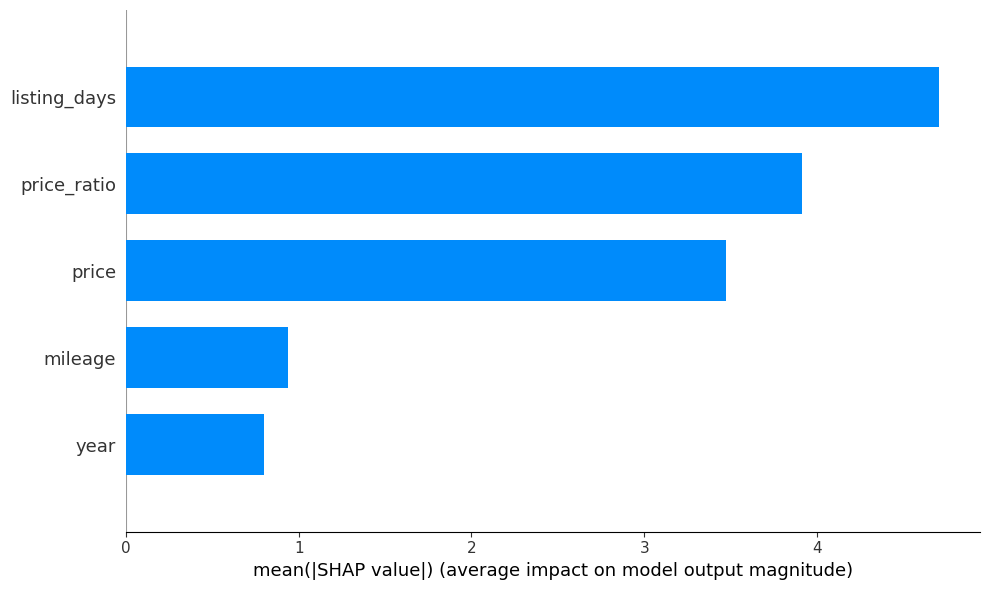

In [73]:
# Только характеристики авто — без производных от контактов
features = ["price", "mileage", "year", "price_ratio", "listing_days"]

X = data_full[features].dropna()
y = data_full.loc[X.index, "total_contacts"]

model = lgb.LGBMRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

X_sample = X.sample(5000, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    plot_size=(10, 6)
)

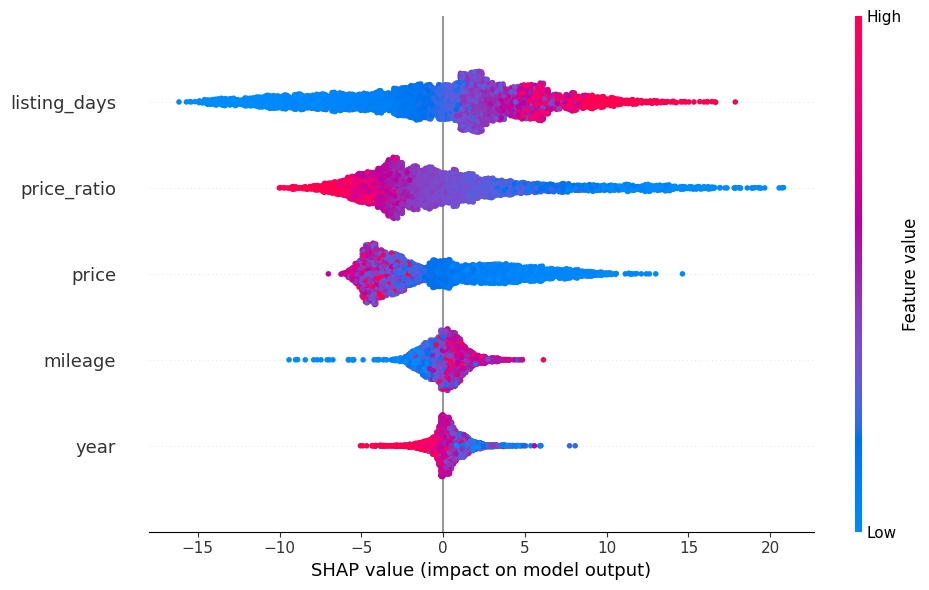

In [74]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_size=(10, 6)
)